In [2]:
import sys
from pathlib import Path

# Add workspace root to path so we can import infraScan
workspace_root = Path("/Users/laura/Desktop/infraScan_lkuehner")
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

print(f"✓ Path setup: {sys.path[0]}")

✓ Path setup: /Users/laura/Desktop/infraScan_lkuehner


In [3]:
import matplotlib

if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__


## To TEST

In [2]:
from infraScan.infraScanIntegrated.plots import plot_canton_zurich_overview
from infraScan.infraScanIntegrated.plots import export_canton_zurich_overview_html

#plot_canton_zurich_overview()
export_canton_zurich_overview_html()


PosixPath('/Volumes/WD_Windows/MSc_Thesis/plots/Integrated/corridor_overview_lightbasemap.html')

In [ ]:
from infraScan.infraScanRail.TT_Delay import analyze_travel_times

analyze_travel_times



In [4]:
from infraScan.infraScanIntegrated import random_scenarios_multimode as integrated_random
import os
from infraScan.infraScanRoad import settings
os.chdir(settings.MAIN)

components = integrated_random.load_shared_scenario_components()

summary_df = integrated_random.build_shared_scenario_summary(
    components,
    valuation_year=2050,   # same default logic as the integrated settings
)

selected_df = integrated_random.select_representative_shared_scenarios(
    summary_df,
    n_representatives=10,
)

selected_scenarios = selected_df["scenario"].tolist()

print(selected_scenarios)
print(selected_df)

['scenario_26', 'scenario_70', 'scenario_89', 'scenario_100', 'scenario_75', 'scenario_96', 'scenario_44', 'scenario_19', 'scenario_64', 'scenario_78']
       scenario  scenario_idx  valuation_year  total_population_start  \
0   scenario_26            25            2050               1516798.0   
1   scenario_70            69            2050               1516798.0   
2   scenario_89            88            2050               1516798.0   
3  scenario_100            99            2050               1516798.0   
4   scenario_75            74            2050               1516798.0   
5   scenario_96            95            2050               1516798.0   
6   scenario_44            43            2050               1516798.0   
7   scenario_19            18            2050               1516798.0   
8   scenario_64            63            2050               1516798.0   
9   scenario_78            77            2050               1516798.0   

   total_population_valuation  population_gr

In [3]:
from infraScan.infraScanIntegrated import random_scenarios_multimode as integrated_random

result = integrated_random.generate_and_apply_shared_scenarios(
    start_year=2018,
    end_year=2100,
    num_of_scenarios=100,
    representative_scenarios_count=3,
    run_road=True,
    run_rail=True,
    do_plot=True,
)

print(result["selected_scenarios"])
print(result["summary_path"])
print(result["selection_path"])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

/opt/anaconda3/envs/infraScan2/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   20.3s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

In [4]:
import pandas as pd
import os
from infraScan.infraScanRoad import settings
from infraScan.infraScanIntegrated import random_scenarios as integrated_random
from infraScan.infraScanIntegrated import paths as integrated_paths

os.chdir(settings.MAIN)

# Lade die bereits gespeicherte Summary (falls vorhanden)
summary_df = pd.read_csv(integrated_paths.SHARED_SUMMARY_PATH)

# Wende deine angepasste select_representative_shared_scenarios() an
selected_df = integrated_random.select_representative_shared_scenarios(
    summary_df,
    n_representatives=3  # oder deine gewünschte Anzahl
)

print(selected_df[['scenario', 'shared_future_score', 'selection_order']])

# Speichern (optional)
integrated_random.save_representative_scenario_selection(selected_df)

      scenario  shared_future_score  selection_order
0  scenario_76             0.275000                1
1  scenario_45             0.496667                2
2  scenario_67             0.745000                3


'data/Scenario/cache/shared/shared_representative_scenarios.csv'

In [ ]:
import os
from infraScan.infraScanRoad import settings
from infraScan.infraScanRoad.scoring import GetVoronoiOD_multi_generated

os.chdir(settings.MAIN)

GetVoronoiOD_multi_generated(
    year=settings.start_valuation_year,
    selected_developments=settings.get_od_debug_development_ids(),
)

/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1054: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD['wert'].loc[(communalOD['quelle_code'] == communalOD['ziel_code'])] = 0
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1061: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD.loc[:, 'wert'] = communalOD['wert'] * tau
Processing generated development ODs:   0%|          | 0/15 [00:00<?, ?it/s]/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1979: PerformanceWarning: dr

Generated development OD export summary: written_files=1500, skipped_no_pairs=0, skipped_missing_raster_mass=0


In [2]:
import os
os.environ['USE_PYGEOS'] = '0'

from infraScan.infraScanRoad import settings
from infraScan.infraScanRoad.scoring import monetize_tts
from infraScan.infraScanRoad.scoring import GetVoronoiOD_multi
from infraScan.infraScanRoad.pipeline import (
    phase_1_initialization,
    phase_2_data_import,
    phase_3_infrastructure_developments,
    phase_5_costs_and_accesibility,
    phase_6_travel_time_savings,
    phase_7_aggregation,
    phase_8_visualization,
 )

os.chdir(settings.MAIN)



runtimes = {}

#limits_corridor, boundary_plot, innerboundary, outerboundary = phase_1_initialization(runtimes)
#phase_2_data_import(limits_corridor, runtimes)
#network, limits_variables, generated_points, current_points, current_access_points = phase_3_infrastructure_developments(innerboundary, outerboundary, runtimes)
#phase_4_scenario_generation(limits_variables, runtimes)

#voronoi_tt = phase_5_costs_and_accesibility(limits_variables, runtimes)
phase_6_travel_time_savings(runtimes)
gdf_costs = phase_7_aggregation(runtimes)
#phase_8_visualization(voronoi_tt, innerboundary, network, boundary_plot,current_access_points, gdf_costs, runtimes)



PHASE 6: TRAVEL TIME SAVINGS

  -> Using travel time savings method: od
  [CHECKPOINT] Skipping: od_matrices_generated
Status quo OD travel times on status-quo Voronoi for scenario: scenario_1
Optimization terminated successfully    (Exit mode 0)
            Current function value: -24527546.265839618
            Iterations: 1
            Function evaluations: 1823
            Gradient evaluations: 1
Status quo OD travel times on status-quo Voronoi for scenario: scenario_30
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7156702.345695858
            Iterations: 1
            Function evaluations: 1833
            Gradient evaluations: 1
Status quo OD travel times on status-quo Voronoi for scenario: scenario_18


/opt/anaconda3/envs/infraScan2/lib/python3.11/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Optimization terminated successfully    (Exit mode 0)
            Current function value: -2864981.0798692903
            Iterations: 1
            Function evaluations: 1833
            Gradient evaluations: 1
  [CHECKPOINT] Saved: tt_optimization_status_quo_by_od
Flag: link_traffic_to_map skipped for GENERATED scenarios


OD TT by development-scenario: 100%|██████████| 3/3 [00:00<00:00, 252.58it/s]
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:2950: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  points = gpd.GeoDataFrame(pd.concat([points, pd.DataFrame(temp).T], ignore_index=True))
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:2950: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  points = gpd.GeoDataFrame(pd.concat([points, pd.DataFrame(temp).T], ignore_index=True))
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:2950: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to 

Development: 2 in scenario: scenario_30
Development: 2 in scenario: scenario_18
Development: 2 in scenario: scenario_1


/opt/anaconda3/envs/infraScan2/lib/python3.11/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Optimization terminated successfully    (Exit mode 0)
            Current function value: -7236400.478503324
            Iterations: 1
            Function evaluations: 1956
            Gradient evaluations: 1
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -8877089.435835604
            Iterations: 1
            Function evaluations: 1945
            Gradient evaluations: 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1783077.545893658
            Iterations: 1
            Function evaluations: 1956
            Gradient evaluations: 1
Flag: tt_optimization_all_developments is complete
  [CHECKPOINT] Saved: tt_optimization_developments_by_od_raster


/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1052: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD['wert'].loc[(communalOD['quelle_code'] == communalOD['ziel_code'])] = 0
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1059: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD.loc[:, 'wert'] = communalOD['wert'] * tau


Saved detailed OD TT savings to: data/infraScanRoad/traffic_flow/od/od_tt_savings_detailed.csv
Saved aggregated TT savings to: data/infraScanRoad/costs/traveltime_savings_od.csv
  [CHECKPOINT] Saved: tt_monetization_od

PHASE 7: COST-BENEFIT INTEGRATION

 -> Aggregate costs
Using travel time savings input: data/infraScanRoad/costs/traveltime_savings_od.csv
Number of developments: 1
   ID_new     cost_path  cost_bridge  cost_tunnel  building_costs  climate_cost  land_realloc        nature      noise_s1      noise_s2      noise_s3   maintenance  tt_scenario_1  tt_scenario_18  tt_scenario_30  externalities_s1  externalities_s2  externalities_s3  construction_maintenance
0       2 -6.998743e+07  -22365000.0         -0.0   -1.943524e+08 -1.411283e+07 -2.682663e+06 -4.276601e+07 -3.830186e+08 -3.510750e+08 -4.149622e+08 -1.437164e+08  -5.203003e+09    7.218534e+08    8.110374e+07     -4.425801e+08     -4.106365e+08     -4.745237e+08             -3.380688e+08
  [CHECKPOINT] Saved: aggregate_c

In [12]:
# Compare aggregate vs OD outputs (no rerun; read existing files only)
from pathlib import Path
import pandas as pd

base = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')

p_tt_agg = base / 'traveltime_savings_aggregate.csv'
p_tt_od = base / 'traveltime_savings_od.csv'
p_tot_agg = base / 'total_costs_aggregate.csv'
p_tot_od = base / 'total_costs_od.csv'

print('--- File existence ---')
for p in [p_tt_agg, p_tt_od, p_tot_agg, p_tot_od]:
    print(f"{p.name}:", 'OK' if p.exists() else 'MISSING')

if not (p_tt_agg.exists() and p_tt_od.exists()):
    print('\nNeed both TT files to compare signs and rankings.')
else:
    tt_agg = pd.read_csv(p_tt_agg)
    tt_od = pd.read_csv(p_tt_od)

    id_col_agg = 'development' if 'development' in tt_agg.columns else 'ID_new'
    id_col_od = 'development' if 'development' in tt_od.columns else 'ID_new'

    tt_cols_agg = sorted([c for c in tt_agg.columns if c.startswith('tt_')])
    tt_cols_od = sorted([c for c in tt_od.columns if c.startswith('tt_')])
    common_tt_cols = sorted(set(tt_cols_agg).intersection(tt_cols_od))

    print('\n--- TT schema ---')
    print('aggregate tt cols:', tt_cols_agg)
    print('od tt cols       :', tt_cols_od)
    print('common tt cols   :', common_tt_cols)

    merged = tt_agg[[id_col_agg] + common_tt_cols].merge(
        tt_od[[id_col_od] + common_tt_cols],
        left_on=id_col_agg,
        right_on=id_col_od,
        suffixes=('_agg', '_od')
    )

    if merged.empty or not common_tt_cols:
        print('\nNo overlap between aggregate and OD TT files to compare.')
    else:
        print(f"\nRows compared: {len(merged)}")

        print('\n--- Sign check (means) ---')
        for c in common_tt_cols:
            m_agg = merged[f'{c}_agg'].mean()
            m_od = merged[f'{c}_od'].mean()
            print(f"{c}: mean_agg={m_agg:,.2f}, mean_od={m_od:,.2f}")

        print('\n--- Magnitude check (mean abs diff after sign-normalizing OD) ---')
        for c in common_tt_cols:
            diff = (merged[f'{c}_agg'] - (-merged[f'{c}_od'])).abs().mean()
            print(f"{c}: mean_abs(agg - (-od)) = {diff:,.2f}")

        print('\n--- Rank agreement by scenario (Spearman) ---')
        for c in common_tt_cols:
            corr = merged[f'{c}_agg'].rank().corr((-merged[f'{c}_od']).rank(), method='spearman')
            print(f"{c}: spearman(rank_agg, rank_-od) = {corr:.4f}")

if p_tot_agg.exists() and p_tot_od.exists():
    tot_agg = pd.read_csv(p_tot_agg)
    tot_od = pd.read_csv(p_tot_od)

    total_cols_agg = sorted([c for c in tot_agg.columns if c.startswith('total_')])
    total_cols_od = sorted([c for c in tot_od.columns if c.startswith('total_')])
    common_total_cols = sorted(set(total_cols_agg).intersection(total_cols_od))

    print('\n--- Total schema ---')
    print('aggregate total cols:', total_cols_agg)
    print('od total cols       :', total_cols_od)
    print('common total cols   :', common_total_cols)

    id_col_agg = 'ID_new' if 'ID_new' in tot_agg.columns else ('development' if 'development' in tot_agg.columns else None)
    id_col_od = 'ID_new' if 'ID_new' in tot_od.columns else ('development' if 'development' in tot_od.columns else None)

    if id_col_agg and id_col_od and common_total_cols:
        tmerged = tot_agg[[id_col_agg] + common_total_cols].merge(
            tot_od[[id_col_od] + common_total_cols],
            left_on=id_col_agg,
            right_on=id_col_od,
            suffixes=('_agg', '_od')
        )
        print(f"\nRows compared (totals): {len(tmerged)}")
        for c in common_total_cols:
            corr = tmerged[f'{c}_agg'].rank().corr(tmerged[f'{c}_od'].rank(), method='spearman')
            mad = (tmerged[f'{c}_agg'] - tmerged[f'{c}_od']).abs().mean()
            print(f"{c}: spearman={corr:.4f}, mean_abs_diff={mad:,.2f}")
else:
    print('\nTotal comparison skipped (missing total_costs_aggregate.csv or total_costs_od.csv).')

--- File existence ---
traveltime_savings_aggregate.csv: OK
traveltime_savings_od.csv: OK
total_costs_aggregate.csv: OK
total_costs_od.csv: OK

--- TT schema ---
aggregate tt cols: ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']
od tt cols       : ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']
common tt cols   : ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']

Rows compared: 12

--- Sign check (means) ---
tt_scenario_28: mean_agg=-41,293,351.90, mean_od=-94,739,571.60
tt_scenario_45: mean_agg=-231,646,174.65, mean_od=-383,914,776.38
tt_scenario_94: mean_agg=-711,992,204.58, mean_od=-4,425,209,136.66

--- Magnitude check (mean abs diff after sign-normalizing OD) ---
tt_scenario_28: mean_abs(agg - (-od)) = 138,250,940.09
tt_scenario_45: mean_abs(agg - (-od)) = 658,840,512.81
tt_scenario_94: mean_abs(agg - (-od)) = 5,825,069,472.25

--- Rank agreement by scenario (Spearman) ---
tt_scenario_28: spearman(rank_agg, rank_-od) = -0.7972
tt_scenario_45: spearman(rank_agg, 

In [6]:
# Compare the two travel-time-savings approaches on the current generated run
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')

tt_od = pd.read_csv(BASE / 'traveltime_savings_od.csv').rename(columns={'ID_new': 'development'})
tt_agg = pd.read_csv(BASE / 'traveltime_savings_aggregate.csv').rename(columns={'ID_new': 'development'})
tot_od = pd.read_csv(BASE / 'total_costs_od.csv').rename(columns={'ID_new': 'development'})
tot_agg = pd.read_csv(BASE / 'total_costs_aggregate.csv').rename(columns={'ID_new': 'development'})

tt_cols_od = sorted(c for c in tt_od.columns if c.startswith('tt_'))
tt_cols_agg = sorted(c for c in tt_agg.columns if c.startswith('tt_'))
common_tt_cols = sorted(set(tt_cols_od).intersection(tt_cols_agg))

print('TT columns (OD):', tt_cols_od)
print('TT columns (Aggregate):', tt_cols_agg)
print('Common scenario columns:', common_tt_cols)

tt_cmp = tt_od[['development'] + common_tt_cols].merge(
    tt_agg[['development'] + common_tt_cols],
    on='development',
    suffixes=('_od', '_agg')
)

tot_cols = [c.replace('tt_', 'total_') for c in common_tt_cols]
tot_cmp = tot_od[['development'] + tot_cols].merge(
    tot_agg[['development'] + tot_cols],
    on='development',
    suffixes=('_od', '_agg')
)

summary_rows = []
for tt_col in common_tt_cols:
    scen = tt_col.replace('tt_', '')
    total_col = f'total_{scen}'

    od_vals = tt_cmp[f'{tt_col}_od'].astype(float)
    agg_vals = tt_cmp[f'{tt_col}_agg'].astype(float)
    total_od_vals = tot_cmp[f'{total_col}_od'].astype(float)
    total_agg_vals = tot_cmp[f'{total_col}_agg'].astype(float)

    delta_tt = od_vals - agg_vals
    delta_total = total_od_vals - total_agg_vals
    residual_non_tt = delta_total - delta_tt

    same_sign = int(((np.sign(od_vals) == np.sign(agg_vals)) | (od_vals.eq(0)) | (agg_vals.eq(0))).sum())
    ratio = np.where(np.abs(agg_vals) > 0, np.abs(od_vals) / np.abs(agg_vals), np.nan)

    summary_rows.append({
        'scenario': scen,
        'n_developments': len(tt_cmp),
        'mean_tt_od': float(od_vals.mean()),
        'mean_tt_agg': float(agg_vals.mean()),
        'median_abs_tt_ratio_od_over_agg': float(np.nanmedian(ratio)),
        'same_tt_sign_count': same_sign,
        'corr_tt': float(pd.Series(od_vals).corr(pd.Series(agg_vals))),
        'mean_total_od': float(total_od_vals.mean()),
        'mean_total_agg': float(total_agg_vals.mean()),
        'max_abs_non_tt_residual': float(np.nanmax(np.abs(residual_non_tt))),
    })

summary = pd.DataFrame(summary_rows)
print('\nSummary by scenario')
display(summary)

detail = pd.DataFrame({'development': tt_cmp['development']})
for tt_col in common_tt_cols:
    scen = tt_col.replace('tt_', '')
    total_col = f'total_{scen}'
    detail[f'{scen}_tt_od'] = tt_cmp[f'{tt_col}_od'].astype(float)
    detail[f'{scen}_tt_agg'] = tt_cmp[f'{tt_col}_agg'].astype(float)
    detail[f'{scen}_tt_gap_od_minus_agg'] = detail[f'{scen}_tt_od'] - detail[f'{scen}_tt_agg']
    detail[f'{scen}_total_od'] = tot_cmp[f'{total_col}_od'].astype(float)
    detail[f'{scen}_total_agg'] = tot_cmp[f'{total_col}_agg'].astype(float)
    detail[f'{scen}_total_gap_od_minus_agg'] = detail[f'{scen}_total_od'] - detail[f'{scen}_total_agg']
    detail[f'{scen}_residual_non_tt'] = detail[f'{scen}_total_gap_od_minus_agg'] - detail[f'{scen}_tt_gap_od_minus_agg']

print('\nPer-development comparison')
display(detail.sort_values('development'))

for tt_col in common_tt_cols:
    scen = tt_col.replace('tt_', '')
    print(f'\nLargest OD-vs-aggregate TT gaps for {scen}')
    cols = [
        'development',
        f'{scen}_tt_od', f'{scen}_tt_agg', f'{scen}_tt_gap_od_minus_agg',
        f'{scen}_total_od', f'{scen}_total_agg', f'{scen}_total_gap_od_minus_agg',
        f'{scen}_residual_non_tt',
    ]
    order = detail[f'{scen}_tt_gap_od_minus_agg'].abs().sort_values(ascending=False).index
    display(detail.loc[order, cols].head(10))

print('\nInterpretation guide:')
print('- residual_non_tt should be near 0 if the non-TT cost blocks are identical across methods.')
print('- A large TT gap with small residual_non_tt means the total-cost difference is really coming from TT.')
print('- Positive tt_gap_od_minus_agg means the OD TT estimate is less negative / more favorable than aggregate.')


TT columns (OD): ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']
TT columns (Aggregate): ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']
Common scenario columns: ['tt_scenario_28', 'tt_scenario_45', 'tt_scenario_94']

Summary by scenario


,scenario,n_developments,mean_tt_od,mean_tt_agg,median_abs_tt_ratio_od_over_agg,same_tt_sign_count,corr_tt,mean_total_od,mean_total_agg,max_abs_non_tt_residual
0,scenario_28,12,"-94,739,571.60","-41,293,351.90",2.47,11,0.89,"-192,308,799.54","-138,862,579.84",0.00
1,scenario_45,12,"-383,914,776.38","-231,646,174.65",1.84,11,0.93,"60,828,430.52","213,097,032.25",0.00
2,scenario_94,12,"-4,425,209,136.66","-711,992,204.58",6.87,11,0.93,"-3,472,730,359.89","240,486,572.20",0.00



Per-development comparison


,development,scenario_28_tt_od,scenario_28_tt_agg,scenario_28_tt_gap_od_minus_agg,scenario_28_total_od,scenario_28_total_agg,scenario_28_total_gap_od_minus_agg,scenario_28_residual_non_tt,scenario_45_tt_od,scenario_45_tt_agg,scenario_45_tt_gap_od_minus_agg,scenario_45_total_od,scenario_45_total_agg,scenario_45_total_gap_od_minus_agg,scenario_45_residual_non_tt,scenario_94_tt_od,scenario_94_tt_agg,scenario_94_tt_gap_od_minus_agg,scenario_94_total_od,scenario_94_total_agg,scenario_94_total_gap_od_minus_agg,scenario_94_residual_non_tt
0,2,"-63,332,581.14","-39,466,464.51","-23,866,116.63","455,333,647.43","479,199,764.05","-23,866,116.63",-0.00,"-336,120,367.83","-221,240,471.26","-114,879,896.57","806,464,436.58","921,344,333.14","-114,879,896.57",0.00,"-4,121,262,420.69","-676,669,333.75","-3,444,593,086.94","-2,394,537,638.39","1,050,055,448.55","-3,444,593,086.94",0.00
1,103,"-70,603,450.98","-43,161,433.41","-27,442,017.57","286,504,314.09","313,946,331.66","-27,442,017.57",0.00,"-347,165,475.91","-242,122,386.79","-105,043,089.11","622,145,251.12","727,188,340.23","-105,043,089.11",0.00,"-4,217,016,432.73","-745,476,940.41","-3,471,539,492.32","-2,674,534,749.46","797,004,742.86","-3,471,539,492.32",0.00
2,201,"-130,741,039.33","-44,139,267.87","-86,601,771.46","-143,980,105.26","-57,378,333.80","-86,601,771.46",-0.00,"-524,134,341.57","-247,563,307.04","-276,571,034.53","110,189,077.76","386,760,112.29","-276,571,034.53",-0.00,"-6,021,497,317.28","-760,818,472.66","-5,260,678,844.62","-4,780,907,213.41","479,771,631.20","-5,260,678,844.62",0.00
3,249,"-134,505,178.09","-44,230,074.40","-90,275,103.69","74,069,371.88","164,344,475.56","-90,275,103.69",0.00,"-512,560,773.37","-248,058,147.17","-264,502,626.20","330,526,635.10","595,029,261.30","-264,502,626.20",-0.00,"-5,811,725,196.40","-763,180,190.53","-5,048,545,005.88","-4,374,586,866.70","673,958,139.17","-5,048,545,005.88",-0.00
4,334,"20,950,010.63","-7,641,911.14","28,591,921.77","-147,840,069.23","-176,431,991.00","28,591,921.77",0.00,"302,919,918.26","-43,242,547.53","346,162,465.79","361,459,249.50","15,296,783.71","346,162,465.79",0.00,"4,260,036,245.24","-132,827,459.18","4,392,863,704.42","4,531,436,514.52","138,572,810.10","4,392,863,704.42",0.00
5,469,"-44,433,368.23","-27,862,457.07","-16,570,911.15","250,119,735.34","266,690,646.50","-16,570,911.15",-0.00,"-239,492,668.95","-156,131,668.46","-83,361,000.48","526,551,386.80","609,912,387.28","-83,361,000.48",0.00,"-2,968,504,111.17","-480,027,646.62","-2,488,476,464.54","-1,761,027,212.04","727,449,252.50","-2,488,476,464.54",0.00
6,662,"-169,096,045.49","-62,246,056.76","-106,849,988.73","-100,113,801.14","6,736,187.60","-106,849,988.73",0.00,"-765,449,005.38","-349,640,709.72","-415,808,295.65","-84,752,704.30","331,055,591.35","-415,808,295.65",0.00,"-9,149,480,847.48","-1,077,861,713.18","-8,071,619,134.29","-7,896,075,372.01","175,543,762.28","-8,071,619,134.29",0.00
7,689,"-91,801,426.37","-45,337,896.67","-46,463,529.70","-2,559,158,748.22","-2,512,695,218.52","-46,463,529.70",0.00,"-400,673,801.77","-254,280,743.23","-146,393,058.54","-2,383,035,629.04","-2,236,642,570.50","-146,393,058.54",-0.00,"-4,713,129,213.29","-781,038,269.09","-3,932,090,944.20","-6,241,419,833.41","-2,309,328,889.20","-3,932,090,944.20",0.00
8,750,"-140,099,942.81","-46,699,775.36","-93,400,167.45","-246,639,087.60","-153,238,920.15","-93,400,167.45",0.00,"-527,834,238.20","-261,901,834.80","-265,932,403.41","-54,777,798.95","211,154,604.46","-265,932,403.41",-0.00,"-5,962,346,891.17","-805,756,557.94","-5,156,590,333.23","-4,946,652,825.82","209,937,507.41","-5,156,590,333.23",0.00
9,775,"-136,888,656.43","-44,770,795.74","-92,117,860.68","-17,999,693.46","74,118,167.23","-92,117,860.68",-0.00,"-568,664,912.51","-251,005,301.43","-317,659,611.08","107,405,982.31","425,065,593.39","-317,659,611.08",0.00,"-6,548,394,734.85","-768,373,345.13","-5,780,021,389.72","-5,350,676,774.52","429,344,615.19","-5,780,021,389.72",0.00



Largest OD-vs-aggregate TT gaps for scenario_28


...


Largest OD-vs-aggregate TT gaps for scenario_45


,development,scenario_45_tt_od,scenario_45_tt_agg,scenario_45_tt_gap_od_minus_agg,scenario_45_total_od,scenario_45_total_agg,scenario_45_total_gap_od_minus_agg,scenario_45_residual_non_tt
6,662,"-765,449,005.38","-349,640,709.72","-415,808,295.65","-84,752,704.30","331,055,591.35","-415,808,295.65",0.00
4,334,"302,919,918.26","-43,242,547.53","346,162,465.79","361,459,249.50","15,296,783.71","346,162,465.79",0.00
9,775,"-568,664,912.51","-251,005,301.43","-317,659,611.08","107,405,982.31","425,065,593.39","-317,659,611.08",0.00
2,201,"-524,134,341.57","-247,563,307.04","-276,571,034.53","110,189,077.76","386,760,112.29","-276,571,034.53",-0.00
8,750,"-527,834,238.20","-261,901,834.80","-265,932,403.41","-54,777,798.95","211,154,604.46","-265,932,403.41",-0.00
3,249,"-512,560,773.37","-248,058,147.17","-264,502,626.20","330,526,635.10","595,029,261.30","-264,502,626.20",-0.00
11,895,"-383,481,409.53","-229,810,065.62","-153,671,343.91","401,792,799.77","555,464,143.68","-153,671,343.91",0.00
7,689,"-400,673,801.77","-254,280,743.23","-146,393,058.54","-2,383,035,629.04","-2,236,642,570.50","-146,393,058.54",-0.00
0,2,"-336,120,367.83","-221,240,471.26","-114,879,896.57","806,464,436.58","921,344,333.14","-114,879,896.57",0.00
1,103,"-347,165,475.91","-242,122,386.79","-105,043,089.11","622,145,251.12","727,188,340.23","-105,043,089.11",0.00



Largest OD-vs-aggregate TT gaps for scenario_94


,development,scenario_94_tt_od,scenario_94_tt_agg,scenario_94_tt_gap_od_minus_agg,scenario_94_total_od,scenario_94_total_agg,scenario_94_total_gap_od_minus_agg,scenario_94_residual_non_tt
6,662,"-9,149,480,847.48","-1,077,861,713.18","-8,071,619,134.29","-7,896,075,372.01","175,543,762.28","-8,071,619,134.29",0.00
9,775,"-6,548,394,734.85","-768,373,345.13","-5,780,021,389.72","-5,350,676,774.52","429,344,615.19","-5,780,021,389.72",0.00
2,201,"-6,021,497,317.28","-760,818,472.66","-5,260,678,844.62","-4,780,907,213.41","479,771,631.20","-5,260,678,844.62",0.00
8,750,"-5,962,346,891.17","-805,756,557.94","-5,156,590,333.23","-4,946,652,825.82","209,937,507.41","-5,156,590,333.23",0.00
3,249,"-5,811,725,196.40","-763,180,190.53","-5,048,545,005.88","-4,374,586,866.70","673,958,139.17","-5,048,545,005.88",-0.00
4,334,"4,260,036,245.24","-132,827,459.18","4,392,863,704.42","4,531,436,514.52","138,572,810.10","4,392,863,704.42",0.00
7,689,"-4,713,129,213.29","-781,038,269.09","-3,932,090,944.20","-6,241,419,833.41","-2,309,328,889.20","-3,932,090,944.20",0.00
11,895,"-4,478,136,868.44","-706,671,827.63","-3,771,465,040.82","-3,183,691,033.92","587,774,006.89","-3,771,465,040.82",0.00
1,103,"-4,217,016,432.73","-745,476,940.41","-3,471,539,492.32","-2,674,534,749.46","797,004,742.86","-3,471,539,492.32",0.00
0,2,"-4,121,262,420.69","-676,669,333.75","-3,444,593,086.94","-2,394,537,638.39","1,050,055,448.55","-3,444,593,086.94",0.00



Interpretation guide:
- residual_non_tt should be near 0 if the non-TT cost blocks are identical across methods.
- A large TT gap with small residual_non_tt means the total-cost difference is really coming from TT.
- Positive tt_gap_od_minus_agg means the OD TT estimate is less negative / more favorable than aggregate.


Approximate backprojection of dev TT onto SQ catchments for dev 2


,scenario,sq_total_weighted_tt,dev_backprojected_total_weighted_tt,tt_savings_backprojected,matched_sq_pairs
0,medium,0.0,0.0,0.0,0



Top positive weighted improvements on SQ catchment basis


,demand_sq,travel_time_sq,origin_sq,destination_sq,allocated_demand,allocated_weighted_tt,travel_time_dev_backprojected,delta_tt,weighted_delta_sq_demand



Top negative weighted improvements on SQ catchment basis


...

,scenario,sq_total_weighted_tt,dev_backprojected_total_weighted_tt,tt_savings_backprojected,matched_sq_pairs
0,medium,0.0,0.0,0.0,0



Top positive weighted improvements on SQ catchment basis


,demand_sq,travel_time_sq,origin_sq,destination_sq,allocated_demand,allocated_weighted_tt,travel_time_dev_backprojected,delta_tt,weighted_delta_sq_demand



Top negative weighted improvements on SQ catchment basis


,demand_sq,travel_time_sq,origin_sq,destination_sq,allocated_demand,allocated_weighted_tt,travel_time_dev_backprojected,delta_tt,weighted_delta_sq_demand


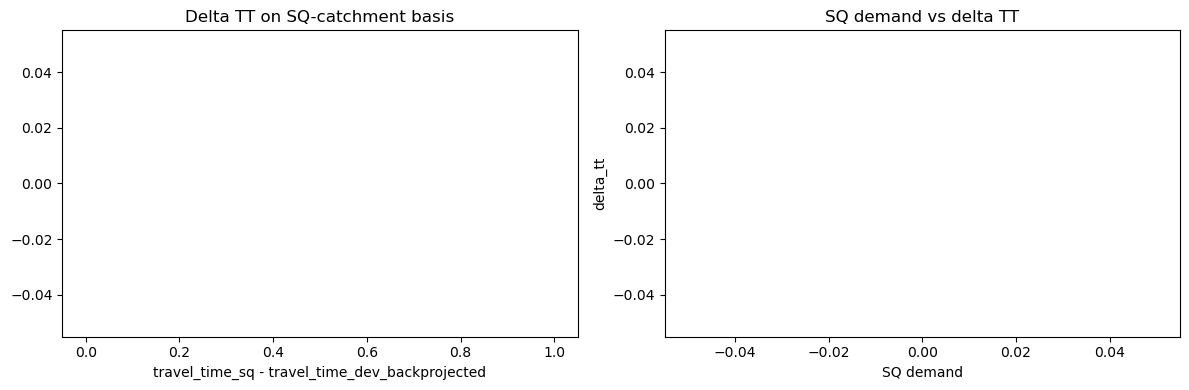

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad')
OD = BASE / 'traffic_flow' / 'od'

DEV_ID = 2
SCENARIO = 'medium'  # low | medium | high

statusquo_raster = BASE / 'Network' / 'travel_time' / 'source_id_raster.tif'
development_raster = BASE / 'Network' / 'travel_time' / 'developments' / f'dev{DEV_ID}_source_id_raster.tif'

sq_tt = pd.read_csv(OD / 'status_quo_od_tt.csv')
dev_tt = pd.read_csv(OD / 'developments_od_tt.csv')

sq_tt = sq_tt[sq_tt['scenario'] == SCENARIO].copy()
dev_tt = dev_tt[(dev_tt['development'] == DEV_ID) & (dev_tt['scenario'] == SCENARIO)].copy()

with rasterio.open(statusquo_raster) as src:
    sq_ids = src.read(1)

with rasterio.open(development_raster) as src:
    dev_ids = src.read(1)

valid = (sq_ids > 0) & (dev_ids > 0)
mapping = pd.DataFrame({
    'sq': sq_ids[valid].astype(int),
    'dev': dev_ids[valid].astype(int),
})
mapping['cell_weight'] = 1.0

# Approximate dev->status-quo backprojection via raster overlap shares.
# If one dev catchment overlaps several SQ catchments, its TT is distributed
# proportionally by overlap share. This is intentionally a smoothed check.
shares = mapping.groupby(['dev', 'sq'], as_index=False)['cell_weight'].sum()
shares['share_dev_to_sq'] = shares['cell_weight'] / shares.groupby('dev')['cell_weight'].transform('sum')

origin_map = shares.rename(columns={'dev': 'origin_dev', 'sq': 'origin_sq', 'share_dev_to_sq': 'origin_share'})[['origin_dev', 'origin_sq', 'origin_share']]
dest_map = shares.rename(columns={'dev': 'destination_dev', 'sq': 'destination_sq', 'share_dev_to_sq': 'destination_share'})[['destination_dev', 'destination_sq', 'destination_share']]

dev_back = dev_tt.merge(origin_map, left_on='origin', right_on='origin_dev', how='left')
dev_back = dev_back.merge(dest_map, left_on='destination', right_on='destination_dev', how='left')
dev_back['pair_share'] = dev_back['origin_share'] * dev_back['destination_share']
dev_back['allocated_demand'] = dev_back['demand'] * dev_back['pair_share']
dev_back['allocated_weighted_tt'] = dev_back['allocated_demand'] * dev_back['travel_time']

dev_on_sq = (
    dev_back.groupby(['origin_sq', 'destination_sq'], as_index=False)
    .agg(
        allocated_demand=('allocated_demand', 'sum'),
        allocated_weighted_tt=('allocated_weighted_tt', 'sum'),
    )
)
dev_on_sq = dev_on_sq[dev_on_sq['allocated_demand'] > 0].copy()
dev_on_sq['travel_time_dev_backprojected'] = dev_on_sq['allocated_weighted_tt'] / dev_on_sq['allocated_demand']

sq_cmp = sq_tt.rename(columns={'origin': 'origin_sq', 'destination': 'destination_sq', 'demand': 'demand_sq', 'travel_time': 'travel_time_sq'})[['origin_sq', 'destination_sq', 'demand_sq', 'travel_time_sq']]

compare = sq_cmp.merge(dev_on_sq, on=['origin_sq', 'destination_sq'], how='inner')
compare['delta_tt'] = compare['travel_time_sq'] - compare['travel_time_dev_backprojected']
compare['weighted_delta_sq_demand'] = compare['demand_sq'] * compare['delta_tt']

summary = pd.DataFrame([{
    'scenario': SCENARIO,
    'sq_total_weighted_tt': float((compare['demand_sq'] * compare['travel_time_sq']).sum()),
    'dev_backprojected_total_weighted_tt': float((compare['demand_sq'] * compare['travel_time_dev_backprojected']).sum()),
    'tt_savings_backprojected': float(compare['weighted_delta_sq_demand'].sum()),
    'matched_sq_pairs': int(len(compare)),
}])

print('Approximate backprojection of dev TT onto SQ catchments for dev', DEV_ID)
display(summary)

print('\nTop positive weighted improvements on SQ catchment basis')
display(compare.sort_values('weighted_delta_sq_demand', ascending=False).head(20))

print('\nTop negative weighted improvements on SQ catchment basis')
display(compare.sort_values('weighted_delta_sq_demand', ascending=True).head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(compare['delta_tt'].dropna(), bins=50)
axes[0].set_title('Delta TT on SQ-catchment basis')
axes[0].set_xlabel('travel_time_sq - travel_time_dev_backprojected')

axes[1].scatter(compare['demand_sq'], compare['delta_tt'], s=8, alpha=0.5)
axes[1].set_title('SQ demand vs delta TT')
axes[1].set_xlabel('SQ demand')
axes[1].set_ylabel('delta_tt')

plt.tight_layout()
plt.show()


## SQ Catchment Reference Debug

Diagnostic only: uses status-quo road catchments as the reference basis and backprojects development travel times onto them.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad')
OD = BASE / 'traffic_flow' / 'od'

DEV_ID = 2
SCENARIO = 'medium'  # low | medium | high

sq_source_path = BASE / 'Network' / 'travel_time' / 'source_id_raster.tif'
dev_source_path = BASE / 'Network' / 'travel_time' / 'developments' / f'dev{DEV_ID}_source_id_raster.tif'
sq_matrix_path = OD / 'scenarios_voronoi' / 'static' / f'od_matrix_{SCENARIO}.csv'

sq_tt = pd.read_csv(OD / 'status_quo_od_tt.csv')
dev_tt = pd.read_csv(OD / 'developments_od_tt.csv')
sq_tt = sq_tt[sq_tt['scenario'] == SCENARIO][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_sq', 'destination': 'destination_sq', 'travel_time': 'tt_sq'})
dev_tt = dev_tt[(dev_tt['development'] == DEV_ID) & (dev_tt['scenario'] == SCENARIO)][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_dev', 'destination': 'destination_dev', 'travel_time': 'tt_dev'})

sq_matrix = pd.read_csv(sq_matrix_path, index_col=0)
sq_matrix.index = pd.to_numeric(sq_matrix.index, errors='coerce')
sq_matrix.columns = pd.to_numeric(sq_matrix.columns, errors='coerce')
sq_matrix = sq_matrix.loc[sq_matrix.index.notna(), sq_matrix.columns.notna()]
sq_matrix = sq_matrix.loc[sq_matrix.index > 0, sq_matrix.columns > 0]
sq_matrix.index = sq_matrix.index.astype(int)
sq_matrix.columns = sq_matrix.columns.astype(int)
sq_od = sq_matrix.stack().rename('demand_sq').reset_index()
sq_od.columns = ['origin_sq', 'destination_sq', 'demand_sq']
sq_od = sq_od[sq_od['origin_sq'] != sq_od['destination_sq']].copy()
sq_od = sq_od[sq_od['demand_sq'] > 0].copy()

with rasterio.open(sq_source_path) as src:
    sq_source = src.read(1)
with rasterio.open(dev_source_path) as src:
    dev_source = src.read(1)

valid = (sq_source > 0) & (dev_source > 0)
mapping = pd.DataFrame({
    'sq': sq_source[valid].astype(int),
    'dev': dev_source[valid].astype(int),
})
mapping['cell_weight'] = 1.0

# Backproject dev catchments to SQ road catchments via raster overlap.
shares = mapping.groupby(['dev', 'sq'], as_index=False)['cell_weight'].sum()
shares['share_dev_to_sq'] = shares['cell_weight'] / shares.groupby('dev')['cell_weight'].transform('sum')
origin_map = shares.rename(columns={'dev': 'origin_dev', 'sq': 'origin_sq', 'share_dev_to_sq': 'origin_share'})[['origin_dev', 'origin_sq', 'origin_share']]
dest_map = shares.rename(columns={'dev': 'destination_dev', 'sq': 'destination_sq', 'share_dev_to_sq': 'destination_share'})[['destination_dev', 'destination_sq', 'destination_share']]

dev_back = dev_tt.merge(origin_map, on='origin_dev', how='left').merge(dest_map, on='destination_dev', how='left')
dev_back['pair_share'] = dev_back['origin_share'] * dev_back['destination_share']
dev_back['weighted_tt_component'] = dev_back['tt_dev'] * dev_back['pair_share']
dev_back_sq = dev_back.groupby(['origin_sq', 'destination_sq'], as_index=False)['weighted_tt_component'].sum().rename(columns={'weighted_tt_component': 'tt_dev_backprojected'})

compare = sq_od.merge(sq_tt, on=['origin_sq', 'destination_sq'], how='left').merge(dev_back_sq, on=['origin_sq', 'destination_sq'], how='left')
compare = compare.dropna(subset=['tt_sq', 'tt_dev_backprojected']).copy()
compare['delta_tt'] = compare['tt_sq'] - compare['tt_dev_backprojected']
compare['weighted_delta'] = compare['demand_sq'] * compare['delta_tt']
compare['weighted_sq_tt'] = compare['demand_sq'] * compare['tt_sq']
compare['weighted_dev_tt'] = compare['demand_sq'] * compare['tt_dev_backprojected']

summary = pd.DataFrame([{
    'scenario': SCENARIO,
    'dev_id': DEV_ID,
    'sq_total_weighted_tt_sq_basis': float(compare['weighted_sq_tt'].sum()),
    'dev_total_weighted_tt_on_sq_basis': float(compare['weighted_dev_tt'].sum()),
    'tt_savings_sq_basis': float(compare['weighted_delta'].sum()),
    'matched_sq_pairs': int(len(compare)),
}])

print('Status-quo road-catchment reference basis for dev', DEV_ID)
display(summary)

print('\nTop positive SQ-catchment-pair contributions')
display(compare.sort_values('weighted_delta', ascending=False).head(20))

print('\nTop negative SQ-catchment-pair contributions')
display(compare.sort_values('weighted_delta', ascending=True).head(20))


Status-quo road-catchment reference basis for dev 2


,scenario,dev_id,sq_total_weighted_tt_sq_basis,dev_total_weighted_tt_on_sq_basis,tt_savings_sq_basis,matched_sq_pairs
0,medium,2,"18,685.82","21,830.47","-3,144.66",927



Top positive SQ-catchment-pair contributions


,origin_sq,destination_sq,demand_sq,tt_sq,tt_dev_backprojected,delta_tt,weighted_delta,weighted_sq_tt,weighted_dev_tt
1768,39,169,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00
2726,169,39,0.02,0.00,0.00,-0.00,-0.00,0.00,0.00
1238,29,168,0.92,0.00,0.00,-0.00,-0.00,0.00,0.00
2663,168,29,2.66,0.00,0.00,-0.00,-0.00,0.01,0.01
896,23,24,0.14,0.01,0.01,-0.00,-0.00,0.00,0.00
1158,28,29,1.78,0.01,0.01,-0.00,-0.00,0.01,0.01
1156,28,26,0.20,0.02,0.02,-0.00,-0.00,0.00,0.00
1133,27,168,0.44,0.02,0.02,-0.00,-0.00,0.01,0.01
1157,28,27,0.58,0.01,0.01,-0.00,-0.00,0.01,0.01
2661,168,26,0.30,0.03,0.03,-0.00,-0.00,0.01,0.01



Top negative SQ-catchment-pair contributions


,origin_sq,destination_sq,demand_sq,tt_sq,tt_dev_backprojected,delta_tt,weighted_delta,weighted_sq_tt,weighted_dev_tt
2778,171,38,206.30,2.05,3.10,-1.05,-216.32,422.87,639.19
1716,38,171,195.44,2.05,3.10,-1.05,-204.93,400.61,605.54
1697,38,40,119.29,2.04,3.09,-1.05,-124.96,243.22,368.18
1802,40,38,105.45,2.04,3.09,-1.05,-110.46,215.00,325.46
1536,35,38,95.47,1.98,2.99,-1.01,-96.77,188.96,285.73
1694,38,36,93.60,1.98,2.99,-1.01,-94.87,185.25,280.12
296,6,38,82.04,1.98,2.99,-1.01,-83.16,162.39,245.54
1669,38,6,71.02,1.98,2.99,-1.01,-71.98,140.56,212.54
1589,36,38,67.19,1.98,2.99,-1.01,-68.10,132.98,201.08
1690,38,32,53.45,1.98,2.99,-1.01,-54.18,105.79,159.97


## Full Raster Basis Debug

Diagnostic only: single-development full raster-basis demand-weighted comparison after routing, computed efficiently via catchment-pair travel times.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import rasterio

# Full raster-basis comparison AFTER routing, demand-weighted correctly.
# We do NOT route raster-to-raster directly. Under the assumption
# tt(a,b) = tt(c(a), c(b)) with c(.) the assigned catchment, the exact raster
# comparison can be computed efficiently from raster-level commune/catchment shares
# and the original commune OD matrix.

ROOT = Path('/Users/laura/Desktop/infraScan_lkuehner')
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from infraScan.infraScanRoad import scoring as road_scoring

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad')
OD = BASE / 'traffic_flow' / 'od'

DEV_ID = 2
SCENARIO = 'medium'  # low | medium | high
band_map = {'medium': 1, 'low': 2, 'high': 3}
band = band_map[SCENARIO]

sq_source_path = BASE / 'Network' / 'travel_time' / 'source_id_raster.tif'
dev_source_path = BASE / 'Network' / 'travel_time' / 'developments' / f'dev{DEV_ID}_source_id_raster.tif'
pop_raster_path = Path('/Volumes/WD_Windows/MSc_Thesis/data/independent_variable/processed/scenario/scen_pop.tif')
empl_raster_path = Path('/Volumes/WD_Windows/MSc_Thesis/data/independent_variable/processed/scenario/scen_empl.tif')

sq_tt = pd.read_csv(OD / 'status_quo_od_tt.csv')
dev_tt = pd.read_csv(OD / 'developments_od_tt.csv')
sq_tt = sq_tt[sq_tt['scenario'] == SCENARIO][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_catchment', 'destination': 'destination_catchment', 'travel_time': 'tt_sq'})
dev_tt = dev_tt[(dev_tt['development'] == DEV_ID) & (dev_tt['scenario'] == SCENARIO)][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_catchment', 'destination': 'destination_catchment', 'travel_time': 'tt_dev'})

with rasterio.open(sq_source_path) as src:
    sq_source = src.read(1)
with rasterio.open(dev_source_path) as src:
    dev_source = src.read(1)
with rasterio.open(pop_raster_path) as src:
    pop = src.read(band).astype(float)
with rasterio.open(empl_raster_path) as src:
    empl = src.read(band).astype(float)

commune_raster, _ = road_scoring.GetCommuneShapes(raster_path=str(sq_source_path))
valid = (sq_source > 0) & (dev_source > 0) & (commune_raster > 0) & np.isfinite(pop) & np.isfinite(empl) & (pop >= 0) & (empl >= 0)
sq_df = pd.DataFrame({'commune_id': commune_raster[valid].astype(int), 'catchment': sq_source[valid].astype(int), 'pop': pop[valid], 'empl': empl[valid]})
dev_df = pd.DataFrame({'commune_id': commune_raster[valid].astype(int), 'catchment': dev_source[valid].astype(int), 'pop': pop[valid], 'empl': empl[valid]})

def shares_by_commune_and_catchment(df):
    origin = df.groupby(['commune_id', 'catchment'], as_index=False)['pop'].sum().rename(columns={'catchment': 'origin_catchment', 'pop': 'origin_mass'})
    dest = df.groupby(['commune_id', 'catchment'], as_index=False)['empl'].sum().rename(columns={'catchment': 'destination_catchment', 'empl': 'dest_mass'})
    origin['origin_total'] = origin.groupby('commune_id')['origin_mass'].transform('sum')
    dest['dest_total'] = dest.groupby('commune_id')['dest_mass'].transform('sum')
    origin['origin_share'] = np.where(origin['origin_total'] > 0, origin['origin_mass'] / origin['origin_total'], 0.0)
    dest['dest_share'] = np.where(dest['dest_total'] > 0, dest['dest_mass'] / dest['dest_total'], 0.0)
    origin = origin.rename(columns={'commune_id': 'origin_commune'})[['origin_commune', 'origin_catchment', 'origin_share']]
    dest = dest.rename(columns={'commune_id': 'destination_commune'})[['destination_commune', 'destination_catchment', 'dest_share']]
    return origin, dest

sq_origin, sq_dest = shares_by_commune_and_catchment(sq_df)
dev_origin, dev_dest = shares_by_commune_and_catchment(dev_df)

od = road_scoring.GetHighwayPHDemandPerCommune()
odmat = road_scoring.GetODMatrix(od).astype(float)
od_long = odmat.stack().rename('od_demand').reset_index()
od_long.columns = ['origin_commune', 'destination_commune', 'od_demand']
od_long = od_long[(od_long['origin_commune'] != od_long['destination_commune']) & (od_long['od_demand'] > 0)].copy()

sq_pairs = od_long.merge(sq_origin, on='origin_commune', how='left').merge(sq_dest, on='destination_commune', how='left').merge(sq_tt, on=['origin_catchment', 'destination_catchment'], how='left')
sq_pairs = sq_pairs.dropna(subset=['tt_sq']).copy()
sq_pairs['pair_demand'] = sq_pairs['od_demand'] * sq_pairs['origin_share'] * sq_pairs['dest_share']
sq_pairs['weighted_tt'] = sq_pairs['pair_demand'] * sq_pairs['tt_sq']

dev_pairs = od_long.merge(dev_origin, on='origin_commune', how='left').merge(dev_dest, on='destination_commune', how='left').merge(dev_tt, on=['origin_catchment', 'destination_catchment'], how='left')
dev_pairs = dev_pairs.dropna(subset=['tt_dev']).copy()
dev_pairs['pair_demand'] = dev_pairs['od_demand'] * dev_pairs['origin_share'] * dev_pairs['dest_share']
dev_pairs['weighted_tt'] = dev_pairs['pair_demand'] * dev_pairs['tt_dev']

summary = pd.DataFrame([{
    'scenario': SCENARIO,
    'dev_id': DEV_ID,
    'sq_total_weighted_tt_full_raster_basis': float(sq_pairs['weighted_tt'].sum()),
    'dev_total_weighted_tt_full_raster_basis': float(dev_pairs['weighted_tt'].sum()),
    'tt_savings_full_raster_basis': float(sq_pairs['weighted_tt'].sum() - dev_pairs['weighted_tt'].sum()),
    'total_od_demand': float(od_long['od_demand'].sum()),
    'sq_pair_rows': int(len(sq_pairs)),
    'dev_pair_rows': int(len(dev_pairs)),
}])

print('Full raster-basis TTT comparison for dev', DEV_ID)
display(summary)

print('\nTop SQ catchment-pair contributions on full raster basis')
display(sq_pairs.sort_values('weighted_tt', ascending=False).head(20))

print('\nTop DEV catchment-pair contributions on full raster basis')
display(dev_pairs.sort_values('weighted_tt', ascending=False).head(20))


Full raster-basis TTT comparison for dev 2


/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1054: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD['wert'].loc[(communalOD['quelle_code'] == communalOD['ziel_code'])] = 0
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1061: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD.loc[:, 'wert'] = communalOD['wert'] * tau


,scenario,dev_id,sq_total_weighted_tt_full_raster_basis,dev_total_weighted_tt_full_raster_basis,tt_savings_full_raster_basis,total_od_demand,sq_pair_rows,dev_pair_rows
0,medium,2,"11,806.57","12,315.02",-508.45,"20,472.32",16350,16634



Top SQ catchment-pair contributions on full raster basis


,origin_commune,destination_commune,od_demand,origin_catchment,origin_share,destination_catchment,dest_share,tt_sq,pair_demand,weighted_tt
6251,54,69,44.97,34.00,0.98,32.00,0.87,1.98,38.34,75.88
13502,69,54,44.97,32.00,0.78,34.00,0.95,1.98,33.50,66.30
41005,199,191,62.44,35.00,0.58,32.00,0.78,1.98,28.19,55.79
13534,69,62,41.43,32.00,0.78,29.00,0.84,2.02,27.08,54.62
41070,199,198,77.69,35.00,0.58,38.00,0.60,1.98,26.95,53.34
35010,191,199,62.44,32.00,0.69,35.00,0.60,1.98,26.03,51.52
6461,54,191,31.89,34.00,0.98,32.00,0.78,1.98,24.36,48.21
9412,62,69,41.43,29.00,0.65,32.00,0.87,2.02,23.40,47.20
32255,177,121,36.79,38.00,0.94,171.00,0.62,2.05,21.43,43.93
34522,191,54,31.89,32.00,0.69,34.00,0.95,1.98,21.02,41.60



Top DEV catchment-pair contributions on full raster basis


,origin_commune,destination_commune,od_demand,origin_catchment,origin_share,destination_catchment,dest_share,tt_dev,pair_demand,weighted_tt
6265,54,69,44.97,34.00,0.98,32.00,0.87,2.03,38.34,77.84
13519,69,54,44.97,32.00,0.78,34.00,0.95,2.03,33.50,68.02
40180,199,191,62.44,35.00,0.58,32.00,0.78,2.03,28.19,57.24
13551,69,62,41.43,32.00,0.78,29.00,0.84,2.07,27.08,56.01
40245,199,198,77.69,35.00,0.58,38.00,0.60,2.03,26.95,54.72
34237,191,199,62.44,32.00,0.69,35.00,0.60,2.03,26.03,52.86
6467,54,191,31.89,34.00,0.98,32.00,0.78,2.03,24.36,49.46
9442,62,69,41.43,29.00,0.65,32.00,0.87,2.07,23.40,48.40
32058,177,121,36.79,"9,999.00",0.95,171.00,0.62,2.14,21.50,46.11
33761,191,54,31.89,32.00,0.69,34.00,0.95,2.03,21.02,42.67


## Main Result - could WORK

Demand-weighted travel-time comparison on a stable raster basis with commune mapping retained. Use this as the main OD-based result.


/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1054: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD['wert'].loc[(communalOD['quelle_code'] == communalOD['ziel_code'])] = 0
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1061: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD.loc[:, 'wert'] = communalOD['wert'] * tau


,development,scenario,sq_total_weighted_tt,dev_total_weighted_tt,tt_savings,sq_pair_rows,dev_pair_rows
0,2,high,14903.820256,15574.423143,-670.602888,16350,16634
1,25,high,14903.820256,0.000000,14903.820256,16350,0
2,27,high,14903.820256,0.000000,14903.820256,16350,0
3,28,high,14903.820256,0.000000,14903.820256,16350,0
4,103,high,14903.820256,15661.169832,-757.349576,16350,17376
5,201,high,14903.820256,15757.993630,-854.173375,16350,17810
6,249,high,14903.820256,15724.206344,-820.386088,16350,17810
7,334,high,14903.820256,14484.964829,418.855427,16350,17140
8,469,high,14903.820256,15386.110372,-482.290116,16350,15866
9,662,high,14903.820256,16230.901775,-1327.081519,16350,17582



Pivoted savings


scenario,high,low,medium
development,,,
2,-670.602888,-384.224367,-508.454494
25,14903.820256,9413.175047,11806.569313
27,14903.820256,9413.175047,11806.569313
28,14903.820256,9413.175047,11806.569313
103,-757.349576,-433.623250,-574.116102
201,-854.173375,-485.140051,-645.221474
249,-820.386088,-468.427809,-620.274878
334,418.855427,228.972020,312.240731
469,-482.290116,-276.268146,-365.660816


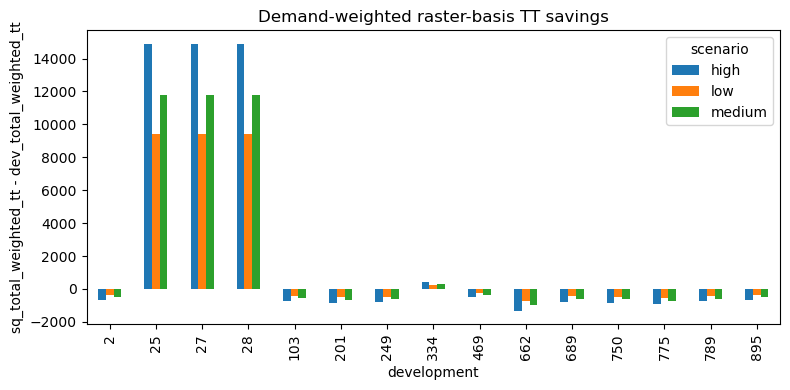

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# This is the main OD-based comparison we currently trust most.
# Idea:
# 1. Keep a stable spatial basis: the same raster cells in SQ and development.
# 2. Keep the original demand basis: commune-to-commune OD demand.
# 3. For each network, map raster cells to that network's catchments.
# 4. Approximate tt(a,b) for raster cells a,b by tt(c(a), c(b)), i.e. the routed
#    travel time between their assigned catchments.
# 5. Weight those catchment-pair travel times by commune OD demand distributed
#    through raster-level population/employment shares.

ROOT = Path('/Users/laura/Desktop/infraScan_lkuehner')
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from infraScan.infraScanRoad import scoring as road_scoring

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad')
OD = BASE / 'traffic_flow' / 'od'

# Choose exactly the developments and scenarios you want to compare here.
DEV_IDS = [2, 103, 469, 895, 249, 662, 201, 689, 775, 28, 750, 789, 27, 25, 334]
SCENARIOS = ['low', 'medium', 'high']

# Scenario bands in the population/employment rasters.
band_map = {'medium': 1, 'low': 2, 'high': 3}

# Stable raster basis:
# - source_id_raster.tif defines the status-quo road catchment assigned to each raster cell.
# - commune_raster gives the commune id of each raster cell on the same grid.
sq_source_path = BASE / 'Network' / 'travel_time' / 'source_id_raster.tif'
pop_raster_path = Path('/Volumes/WD_Windows/MSc_Thesis/data/independent_variable/processed/scenario/scen_pop.tif')
empl_raster_path = Path('/Volumes/WD_Windows/MSc_Thesis/data/independent_variable/processed/scenario/scen_empl.tif')

# Routed OD travel times between catchments, already produced in phase 6.
# SQ uses SQ catchments; each development uses its own catchments.
sq_tt_all = pd.read_csv(OD / 'status_quo_od_tt.csv')
dev_tt_all = pd.read_csv(OD / 'developments_od_tt.csv')

# Original demand basis: commune -> commune highway demand.
od = road_scoring.GetHighwayPHDemandPerCommune()
odmat = road_scoring.GetODMatrix(od).astype(float)
od_long = odmat.stack().rename('od_demand').reset_index()
od_long.columns = ['origin_commune', 'destination_commune', 'od_demand']
od_long = od_long[(od_long['origin_commune'] != od_long['destination_commune']) & (od_long['od_demand'] > 0)].copy()

with rasterio.open(sq_source_path) as src:
    sq_source = src.read(1)
commune_raster, _ = road_scoring.GetCommuneShapes(raster_path=str(sq_source_path))

def shares_by_commune_and_catchment(df):
    # For each commune, compute how much of its origin mass (population) sits in each catchment
    # and how much of its destination mass (employment) sits in each catchment.
    # These shares are the bridge from commune demand to catchment-pair demand.
    origin = df.groupby(['commune_id', 'catchment'], as_index=False)['pop'].sum().rename(columns={'catchment': 'origin_catchment', 'pop': 'origin_mass'})
    dest = df.groupby(['commune_id', 'catchment'], as_index=False)['empl'].sum().rename(columns={'catchment': 'destination_catchment', 'empl': 'dest_mass'})
    origin['origin_total'] = origin.groupby('commune_id')['origin_mass'].transform('sum')
    dest['dest_total'] = dest.groupby('commune_id')['dest_mass'].transform('sum')
    origin['origin_share'] = np.where(origin['origin_total'] > 0, origin['origin_mass'] / origin['origin_total'], 0.0)
    dest['dest_share'] = np.where(dest['dest_total'] > 0, dest['dest_mass'] / dest['dest_total'], 0.0)
    origin = origin.rename(columns={'commune_id': 'origin_commune'})[['origin_commune', 'origin_catchment', 'origin_share']]
    dest = dest.rename(columns={'commune_id': 'destination_commune'})[['destination_commune', 'destination_catchment', 'dest_share']]
    return origin, dest

rows = []
for scen in SCENARIOS:
    band = band_map[scen]
    with rasterio.open(pop_raster_path) as src:
        pop = src.read(band).astype(float)
    with rasterio.open(empl_raster_path) as src:
        empl = src.read(band).astype(float)

    # Status-quo catchment-pair travel times for this scenario.
    sq_tt = sq_tt_all[sq_tt_all['scenario'] == scen][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_catchment', 'destination': 'destination_catchment', 'travel_time': 'tt_sq'})

    # Build the SQ raster -> commune -> catchment allocation.
    valid_sq = (sq_source > 0) & (commune_raster > 0) & np.isfinite(pop) & np.isfinite(empl) & (pop >= 0) & (empl >= 0)
    sq_df = pd.DataFrame({'commune_id': commune_raster[valid_sq].astype(int), 'catchment': sq_source[valid_sq].astype(int), 'pop': pop[valid_sq], 'empl': empl[valid_sq]})
    sq_origin, sq_dest = shares_by_commune_and_catchment(sq_df)

    # Distribute each commune OD flow over SQ catchment pairs using raster-derived shares.
    # pair_demand = commune OD * origin share in origin catchment * destination share in destination catchment
    sq_pairs = od_long.merge(sq_origin, on='origin_commune', how='left').merge(sq_dest, on='destination_commune', how='left').merge(sq_tt, on=['origin_catchment', 'destination_catchment'], how='left')
    sq_pairs = sq_pairs.dropna(subset=['tt_sq']).copy()
    sq_pairs['pair_demand'] = sq_pairs['od_demand'] * sq_pairs['origin_share'] * sq_pairs['dest_share']
    sq_pairs['weighted_tt'] = sq_pairs['pair_demand'] * sq_pairs['tt_sq']
    sq_total = float(sq_pairs['weighted_tt'].sum())

    for dev_id in DEV_IDS:
        dev_source_path = BASE / 'Network' / 'travel_time' / 'developments' / f'dev{dev_id}_source_id_raster.tif'
        with rasterio.open(dev_source_path) as src:
            dev_source = src.read(1)

        # Development catchment-pair travel times for this development and scenario.
        dev_tt = dev_tt_all[(dev_tt_all['development'] == dev_id) & (dev_tt_all['scenario'] == scen)][['origin', 'destination', 'travel_time']].rename(columns={'origin': 'origin_catchment', 'destination': 'destination_catchment', 'travel_time': 'tt_dev'})

        # Build the development raster -> commune -> catchment allocation on the same raster basis.
        valid_dev = (dev_source > 0) & (commune_raster > 0) & np.isfinite(pop) & np.isfinite(empl) & (pop >= 0) & (empl >= 0)
        dev_df = pd.DataFrame({'commune_id': commune_raster[valid_dev].astype(int), 'catchment': dev_source[valid_dev].astype(int), 'pop': pop[valid_dev], 'empl': empl[valid_dev]})
        dev_origin, dev_dest = shares_by_commune_and_catchment(dev_df)

        # Distribute the SAME commune OD demand over DEVELOPMENT catchment pairs.
        # This is the key step: commune demand is retained, but the within-commune spatial split
        # changes because raster cells may belong to different catchments in the development.
        dev_pairs = od_long.merge(dev_origin, on='origin_commune', how='left').merge(dev_dest, on='destination_commune', how='left').merge(dev_tt, on=['origin_catchment', 'destination_catchment'], how='left')
        dev_pairs = dev_pairs.dropna(subset=['tt_dev']).copy()
        dev_pairs['pair_demand'] = dev_pairs['od_demand'] * dev_pairs['origin_share'] * dev_pairs['dest_share']
        dev_pairs['weighted_tt'] = dev_pairs['pair_demand'] * dev_pairs['tt_dev']
        dev_total = float(dev_pairs['weighted_tt'].sum())

        rows.append({
            'development': dev_id,
            'scenario': scen,
            'sq_total_weighted_tt': sq_total,
            'dev_total_weighted_tt': dev_total,
            'tt_savings': sq_total - dev_total,
            'sq_pair_rows': int(len(sq_pairs)),
            'dev_pair_rows': int(len(dev_pairs)),
        })

summary = pd.DataFrame(rows).sort_values(['scenario', 'development']).reset_index(drop=True)
display(summary)
pivot = summary.pivot(index='development', columns='scenario', values='tt_savings')
print('\nPivoted savings')
display(pivot)
fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax)
ax.set_title('Demand-weighted raster-basis TT savings')
ax.set_ylabel('sq_total_weighted_tt - dev_total_weighted_tt')
plt.tight_layout()
plt.show()


## Raster-Basis Total Costs

Compute monetized travel-time benefits and total costs from the main raster-basis OD result, then compare with aggregate total costs.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd


ROOT = Path('/Users/laura/Desktop/infraScan_lkuehner')
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from infraScan.infraScanRoad import settings as road_settings

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad')
COSTS = BASE / 'costs'

# Uses `summary` from the Main Result cell above.
# summary columns include: development, scenario, tt_savings

travel_time_factor = road_settings.VTTS * 2.5 * 250 * road_settings.travel_time_duration
print(f'Monetization factor used: {travel_time_factor:,.2f}')

# Pivot raster-basis TT savings into low/medium/high columns.
summary_pivot = summary.pivot(index='development', columns='scenario', values='tt_savings').reset_index()
summary_pivot = summary_pivot.rename(columns={
    'development': 'ID_new',
    'low': 'tt_low_raster',
    'medium': 'tt_medium_raster',
    'high': 'tt_high_raster',
})

# Monetize the new TT savings using the same factor as the road model.
for scen in ['low', 'medium', 'high']:
    summary_pivot[f'tt_{scen}'] = summary_pivot[f'tt_{scen}_raster'] * travel_time_factor

# Recreate aggregate_costs() with the new raster-basis TT values.
c_construction = gpd.read_file(COSTS / 'construction.gpkg')
c_maintenance = gpd.read_file(COSTS / 'maintenance.gpkg')
c_access = pd.read_csv(COSTS / 'local_accessibility.csv')
c_externalities = gpd.read_file(COSTS / 'externalities.gpkg')
c_noise = gpd.read_file(COSTS / 'noise.gpkg')
agg_total = pd.read_csv(COSTS / 'total_costs_aggregate.csv')

local_columns = [col for col in c_access.columns if col.startswith('local_')]
if not local_columns:
    raise ValueError('No local accessibility columns found in local_accessibility.csv')

c_access = c_access[['ID_develop'] + local_columns].rename(columns={'ID_develop': 'ID_new'})

base = c_construction.drop(columns=['geometry']).merge(
    c_maintenance.drop(columns=['geometry']), how='inner', on='ID_new'
)
base = base.merge(c_access, how='inner', on='ID_new')
base = base.merge(summary_pivot[['ID_new', 'tt_low', 'tt_medium', 'tt_high']], how='inner', on='ID_new')
base = base.merge(c_externalities.drop(columns=['geometry']), how='inner', on='ID_new')
base = base.merge(c_noise.drop(columns=['geometry']), how='inner', on='ID_new')

cost_columns = [
    'cost_path', 'cost_bridge', 'cost_tunnel', 'building_costs', 'climate_cost',
    'land_realloc', 'nature', 'noise_s1', 'noise_s2', 'noise_s3', 'maintenance'
]
for column in cost_columns:
    if column in base.columns:
        base[column] = base[column] * -1

base['externalities_s1'] = base['climate_cost'] + base['land_realloc'] + base['nature'] + base['noise_s1']
base['externalities_s2'] = base['climate_cost'] + base['land_realloc'] + base['nature'] + base['noise_s2']
base['externalities_s3'] = base['climate_cost'] + base['land_realloc'] + base['nature'] + base['noise_s3']
base['construction_maintenance'] = base['building_costs'] + base['maintenance']

local_low_col = 'local_s2' if 'local_s2' in base.columns else ('local_s2_pop' if 'local_s2_pop' in base.columns else local_columns[0])
local_medium_col = 'local_s1' if 'local_s1' in base.columns else ('local_s1_pop' if 'local_s1_pop' in base.columns else local_columns[0])
local_high_col = 'local_s3' if 'local_s3' in base.columns else ('local_s3_pop' if 'local_s3_pop' in base.columns else local_columns[0])

base['total_low_raster'] = base[['construction_maintenance', local_low_col, 'tt_low', 'externalities_s2']].sum(axis=1)
base['total_medium_raster'] = base[['construction_maintenance', local_medium_col, 'tt_medium', 'externalities_s1']].sum(axis=1)
base['total_high_raster'] = base[['construction_maintenance', local_high_col, 'tt_high', 'externalities_s3']].sum(axis=1)

compare = base[['ID_new', 'tt_low', 'tt_medium', 'tt_high', 'total_low_raster', 'total_medium_raster', 'total_high_raster']].merge(
    agg_total[['ID_new', 'total_low', 'total_medium', 'total_high']],
    how='left', on='ID_new'
)
compare = compare[compare['ID_new'].isin(summary_pivot['ID_new'])].sort_values('ID_new').reset_index(drop=True)

display(compare)

print('Difference vs aggregate total costs')
diff = compare[['ID_new']].copy()
diff['diff_low'] = compare['total_low_raster'] - compare['total_low']
diff['diff_medium'] = compare['total_medium_raster'] - compare['total_medium']
diff['diff_high'] = compare['total_high_raster'] - compare['total_high']
display(diff)


Monetization factor used: 1,006,250.00


,ID_new,tt_low,tt_medium,tt_high,total_low_raster,total_medium_raster,total_high_raster,total_low,total_medium,total_high
0,2,-3.866258e+08,-5.116323e+08,-6.747942e+08,6.304310e+08,6.153361e+08,5.620860e+08,9.013588e+08,8.259544e+08,7.471514e+08
1,103,-4.363334e+08,-5.777043e+08,-7.620830e+08,4.110843e+08,3.761054e+08,2.981188e+08,6.952292e+08,6.136144e+08,5.282283e+08
2,201,-4.881722e+08,-6.492541e+08,-8.595120e+08,2.503262e+07,-3.716795e+07,-1.485444e+08,3.434600e+08,2.388941e+08,1.300402e+08
3,249,-4.713555e+08,-6.241516e+08,-8.255135e+08,2.514789e+08,1.982972e+08,9.654968e+07,5.595850e+08,4.612714e+08,3.589395e+08
4,334,2.304031e+08,3.141922e+08,4.214733e+08,2.562607e+08,3.660535e+08,4.993381e+08,4.299846e+07,1.523992e+07,-1.255660e+07
5,469,-2.779948e+08,-3.679462e+08,-4.853044e+08,4.020398e+08,3.877733e+08,3.461000e+08,6.036680e+08,5.417416e+08,4.774084e+08
6,662,-7.502437e+08,-1.004031e+09,-1.335376e+09,-2.084486e+08,-3.403273e+08,-5.497634e+08,2.397968e+08,1.463720e+08,4.706992e+07
7,689,-4.607362e+08,-6.129795e+08,-8.092232e+08,-2.532176e+09,-2.609328e+09,-2.730481e+09,-2.265401e+09,-2.352837e+09,-2.444147e+09
8,750,-4.821234e+08,-6.403740e+08,-8.471418e+08,-1.176066e+08,-1.850944e+08,-3.010994e+08,1.820284e+08,8.670680e+07,-1.279362e+07
9,775,-5.293113e+08,-7.097685e+08,-9.439329e+08,2.529923e+07,-5.468981e+07,-1.883860e+08,3.582732e+08,2.734166e+08,1.847466e+08


Difference vs aggregate total costs


,ID_new,diff_low,diff_medium,diff_high
0,2,-2.709279e+08,-2.106183e+08,-1.850654e+08
1,103,-2.841449e+08,-2.375089e+08,-2.301095e+08
2,201,-3.184274e+08,-2.760620e+08,-2.785846e+08
3,249,-3.081060e+08,-2.629742e+08,-2.623898e+08
4,334,2.132622e+08,3.508135e+08,5.118948e+08
5,469,-2.016282e+08,-1.539683e+08,-1.313084e+08
6,662,-4.482453e+08,-4.866993e+08,-5.968334e+08
7,689,-2.667750e+08,-2.564909e+08,-2.863335e+08
8,750,-2.996351e+08,-2.718012e+08,-2.883058e+08
9,775,-3.329739e+08,-3.281065e+08,-3.731326e+08


## Total Costs Plot

Plot raster-basis total costs against aggregate total costs for each scenario.


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')
agg_total = pd.read_csv(BASE / 'total_costs_aggregate.csv')

# Reuse the raster total-cost table from the previous cell if it exists.
# If not, rebuild a compact one from `compare`.
if 'compare' not in globals():
    raise RuntimeError('Please run the Raster-Basis Total Costs cell first.')

plot_df = compare[['ID_new', 'total_low_raster', 'total_medium_raster', 'total_high_raster']].merge(
    agg_total[['ID_new', 'total_low', 'total_medium', 'total_high']],
    on='ID_new', how='left'
).sort_values('ID_new').reset_index(drop=True)

display(plot_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
scenario_map = [
    ('low', 'Low'),
    ('medium', 'Medium'),
    ('high', 'High'),
]

for ax, (scen, title) in zip(axes, scenario_map):
    x = range(len(plot_df))
    ax.bar([i - 0.2 for i in x], plot_df[f'total_{scen}_raster'], width=0.4, label='Raster OD')
    ax.bar([i + 0.2 for i in x], plot_df[f'total_{scen}'], width=0.4, label='Aggregate')
    ax.set_title(title)
    ax.set_xticks(list(x))
    ax.set_xticklabels(plot_df['ID_new'].astype(int), rotation=60)
    ax.axhline(0, color='black', linewidth=0.8)

axes[0].set_ylabel('Total costs / benefits')
axes[0].legend()
fig.suptitle('Total costs: raster-basis OD vs aggregate')
plt.tight_layout()
plt.show()

# Optional: scatter for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (scen, title) in zip(axes, scenario_map):
    ax.scatter(plot_df[f'total_{scen}'], plot_df[f'total_{scen}_raster'])
    minv = min(plot_df[f'total_{scen}'].min(), plot_df[f'total_{scen}_raster'].min())
    maxv = max(plot_df[f'total_{scen}'].max(), plot_df[f'total_{scen}_raster'].max())
    ax.plot([minv, maxv], [minv, maxv], linestyle='--')
    for _, row in plot_df.iterrows():
        ax.annotate(str(int(row['ID_new'])), (row[f'total_{scen}'], row[f'total_{scen}_raster']), fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Aggregate total cost')
    ax.set_ylabel('Raster OD total cost')
plt.tight_layout()
plt.show()


RuntimeError: Please run the Raster-Basis Total Costs cell first.

,development,scenario45_total_mio_chf_at_base,scenario45_tt_component_mio_chf_at_base,scenario45_local_component_mio_chf_at_base,non_vtts_rest_mio_chf,vtts_for_zero_net_benefit
0,2,806.46,-336.12,1923.23,-780.65,15.84
1,103,622.15,-347.17,1887.72,-918.41,19.20
5,469,526.55,-239.49,1451.67,-685.62,18.21
11,895,401.79,-383.48,1678.39,-893.11,22.21
4,334,361.46,302.92,699.81,-641.27,20.59
3,249,330.53,-512.56,1962.85,-1119.77,24.86
2,201,110.19,-524.13,2004.16,-1369.83,29.80
9,775,107.41,-568.66,1726.09,-1050.02,29.21
10,789,-14.03,-304.32,1580.50,-1290.21,32.55
8,750,-54.78,-527.83,1790.74,-1317.68,33.60


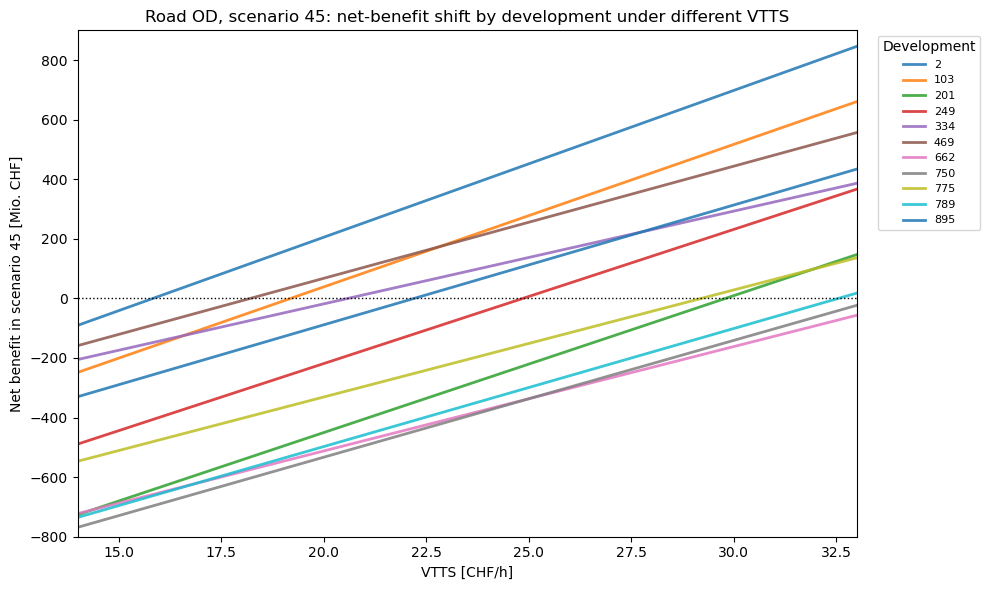

,VTTS_CHF_per_h,mean,median,positive_count
0,14.00,-668.73,-518.00,0
1,14.25,-658.71,-507.87,0
2,14.50,-648.69,-497.75,0
3,14.75,-638.66,-487.63,0
4,15.00,-628.64,-477.50,0
...,...,...,...,...
72,32.00,52.81,211.26,8
73,32.25,62.83,222.63,8
74,32.50,72.85,234.01,8
75,32.75,82.88,245.38,9


In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROAD_COSTS = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')
BASE_VTTS = 32.2  # current Road VTTS in CHF/h from infraScanRoad/settings.py
VTTS_VALUES = np.arange(14.0, 33.0 + 0.001, 0.25)
SCENARIO = 45

total_df = pd.read_csv(ROAD_COSTS / 'total_costs_od.csv')
tt_df = pd.read_csv(ROAD_COSTS / 'traveltime_savings_od.csv')
local_df = pd.read_csv(ROAD_COSTS / 'local_accessibility.csv')

merged = total_df.merge(tt_df, left_on='ID_new', right_on='development', how='inner')
merged = merged.merge(local_df[['ID_develop', f'local_scenario_{SCENARIO}']], left_on='ID_new', right_on='ID_develop', how='left')
total_col = f'total_scenario_{SCENARIO}'
tt_col = f'tt_scenario_{SCENARIO}'
local_col = f'local_scenario_{SCENARIO}'

records = []
for _, row in merged.iterrows():
    for vtts in VTTS_VALUES:
        scale = vtts / BASE_VTTS
        non_vtts_rest = row[total_col] - row[tt_col] - row[local_col]
        scaled_total = non_vtts_rest + row[tt_col] * scale + row[local_col] * scale
        records.append({
            'development': int(row['ID_new']),
            'VTTS_CHF_per_h': vtts,
            'net_benefit_mio_chf': scaled_total / 1e6,
        })

road45_vtts = pd.DataFrame(records)

crossing_rows = []
for _, row in merged.iterrows():
    slope = (row[tt_col] + row[local_col]) / BASE_VTTS
    intercept = row[total_col] - row[tt_col] - row[local_col]
    if slope != 0:
        vtts_zero = -intercept / slope
    else:
        vtts_zero = np.nan
    crossing_rows.append({
        'development': int(row['ID_new']),
        'scenario45_total_mio_chf_at_base': row[total_col] / 1e6,
        'scenario45_tt_component_mio_chf_at_base': row[tt_col] / 1e6,
        'scenario45_local_component_mio_chf_at_base': row[local_col] / 1e6,
        'non_vtts_rest_mio_chf': (row[total_col] - row[tt_col] - row[local_col]) / 1e6,
        'vtts_for_zero_net_benefit': vtts_zero,
    })

crossing_df = pd.DataFrame(crossing_rows).sort_values('scenario45_total_mio_chf_at_base', ascending=False)
display(crossing_df.round(2))

plot_ids = [dev for dev in crossing_df['development'].tolist() if dev != 689]
plot_data = road45_vtts[road45_vtts['development'].isin(plot_ids)]

fig, ax = plt.subplots(figsize=(10, 6))
for dev, grp in plot_data.groupby('development'):
    ax.plot(grp['VTTS_CHF_per_h'], grp['net_benefit_mio_chf'], linewidth=2, alpha=0.85, label=str(dev))

ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('VTTS [CHF/h]')
ax.set_xlim(14, 33)
ax.set_ylim(-800, 900)
ax.set_ylabel('Net benefit in scenario 45 [Mio. CHF]')
ax.set_title('Road OD, scenario 45: net-benefit shift by development under different VTTS')
ax.legend(title='Development', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

summary = road45_vtts.groupby('VTTS_CHF_per_h')['net_benefit_mio_chf'].agg(['mean', 'median'])
summary['positive_count'] = road45_vtts.groupby('VTTS_CHF_per_h')['net_benefit_mio_chf'].apply(lambda s: (s > 0).sum())
display(summary.reset_index().round(2))


,development,tt_component_mio_chf_at_base,local_component_mio_chf_at_base,non_vtts_rest_mio_chf,base_total_mio_chf,vtts_for_zero_net_benefit
1,2,-626.80,1714.92,-748.71,339.42,22.16
15,103,-629.59,1675.24,-885.51,160.13,27.27
116,895,-606.39,1509.20,-856.61,46.19,30.55
56,469,-585.05,1276.78,-654.52,37.21,30.47
33,249,-765.80,1800.18,-1073.59,-39.21,33.42
...,...,...,...,...,...,...
81,648,-649.47,42.41,-2514.53,-3121.59,-133.38
73,594,-644.24,331.88,-3097.11,-3409.47,-319.27
121,952,-891.31,1266.49,-3805.58,-3430.41,326.62
70,558,-845.99,1404.15,-4825.27,-4267.11,278.37


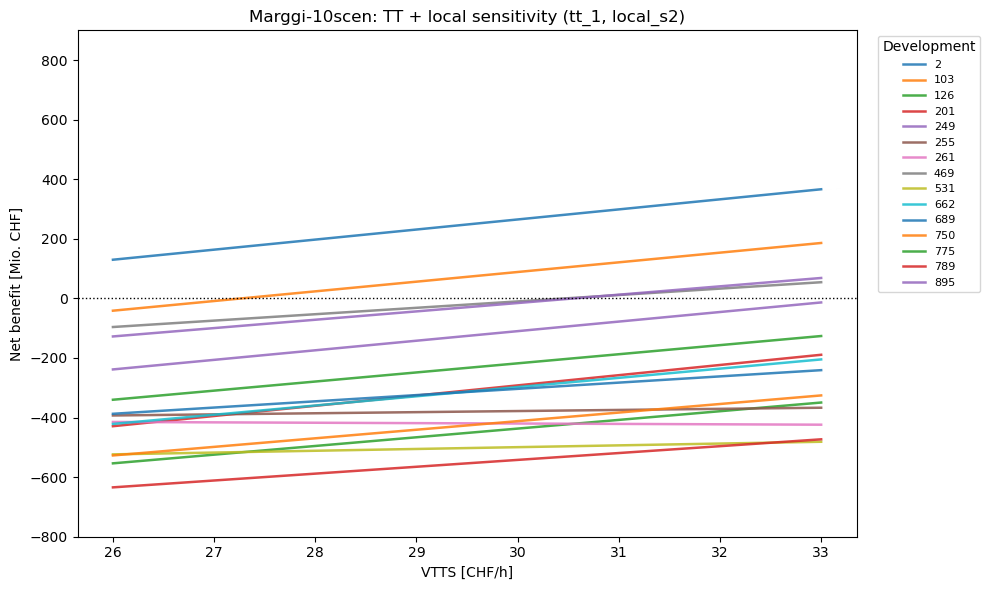

,VTTS_CHF_per_h,mean,median,positive_count
0,26.00,-1319.67,-1026.43,1
1,26.25,-1319.28,-1028.08,1
2,26.50,-1318.88,-1031.69,1
3,26.75,-1318.49,-1033.37,1
4,27.00,-1318.09,-1035.06,1
5,27.25,-1317.70,-1036.74,1
6,27.50,-1317.30,-1038.42,2
7,27.75,-1316.91,-1040.11,2
8,28.00,-1316.51,-1041.79,2
9,28.25,-1316.12,-1043.47,2


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs/Marggi-10scen')
BASE_VTTS = 32.2
VTTS_VALUES = np.arange(26.0, 33.0 + 0.001, 0.25)

# Adjustable assumptions for the older Marggi files
TT_COL = 'tt_1'
LOCAL_COL = 'local_s2'
NOISE_COL = 'noise_s2'

tt_df = pd.read_csv(BASE / 'traveltime_savings.csv')[['development', TT_COL]]
local_df = pd.read_csv(BASE / 'local_accessibility.csv')[['ID_develop', LOCAL_COL]]
construction = gpd.read_file(BASE / 'construction.gpkg')[['ID_new', 'building_costs']]
maintenance = gpd.read_file(BASE / 'maintenance.gpkg')[['ID_new', 'maintenance']]
external = gpd.read_file(BASE / 'externalities.gpkg')[['ID_new', 'climate_cost', 'land_realloc', 'nature']]
noise = gpd.read_file(BASE / 'noise.gpkg')[['ID_new', NOISE_COL]]

marggi = construction.merge(maintenance, on='ID_new').merge(external, on='ID_new').merge(noise, on='ID_new').merge(tt_df, left_on='ID_new', right_on='development').merge(local_df, left_on='ID_new', right_on='ID_develop', how='left')
marggi['non_vtts_rest'] = -(
    marggi['building_costs']
    + marggi['maintenance']
    + marggi['climate_cost']
    + marggi['land_realloc']
    + marggi['nature']
    + marggi[NOISE_COL]
)

records = []
for _, row in marggi.iterrows():
    for vtts in VTTS_VALUES:
        scale = vtts / BASE_VTTS
        scaled_total = row['non_vtts_rest'] + row[TT_COL] * scale + row[LOCAL_COL] * scale
        records.append({
            'development': int(row['ID_new']),
            'VTTS_CHF_per_h': vtts,
            'net_benefit_mio_chf': scaled_total / 1e6,
        })

marggi_tt_local = pd.DataFrame(records)

crossing_rows = []
for _, row in marggi.iterrows():
    slope = (row[TT_COL] + row[LOCAL_COL]) / BASE_VTTS
    intercept = row['non_vtts_rest']
    vtts_zero = (-intercept / slope) if slope != 0 else np.nan
    base_total = row['non_vtts_rest'] + row[TT_COL] + row[LOCAL_COL]
    crossing_rows.append({
        'development': int(row['ID_new']),
        'tt_component_mio_chf_at_base': row[TT_COL] / 1e6,
        'local_component_mio_chf_at_base': row[LOCAL_COL] / 1e6,
        'non_vtts_rest_mio_chf': row['non_vtts_rest'] / 1e6,
        'base_total_mio_chf': base_total / 1e6,
        'vtts_for_zero_net_benefit': vtts_zero,
    })

crossing_df = pd.DataFrame(crossing_rows).sort_values('base_total_mio_chf', ascending=False)
display(crossing_df.round(2))

plot_ids = crossing_df.head(15)['development']
plot_data = marggi_tt_local[marggi_tt_local['development'].isin(plot_ids)]

fig, ax = plt.subplots(figsize=(10, 6))
for dev, grp in plot_data.groupby('development'):
    ax.plot(grp['VTTS_CHF_per_h'], grp['net_benefit_mio_chf'], linewidth=1.8, alpha=0.85, label=str(dev))
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('VTTS [CHF/h]')
ax.set_ylim(-800, 900)
ax.set_ylabel('Net benefit [Mio. CHF]')
ax.set_title(f'Marggi-10scen: TT + local sensitivity ({TT_COL}, {LOCAL_COL})')
ax.legend(title='Development', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

summary = marggi_tt_local.groupby('VTTS_CHF_per_h')['net_benefit_mio_chf'].agg(['mean', 'median'])
summary['positive_count'] = marggi_tt_local.groupby('VTTS_CHF_per_h')['net_benefit_mio_chf'].apply(lambda s: (s > 0).sum())
display(summary.reset_index().round(2))


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/traffic_flow/developments')
DEV = 334
SCEN = 'scenario_45'

sq_tt = pd.read_csv(BASE / 'tt_i' / f'intTrec_i_status_quo_{SCEN}.csv', header=None)[0].to_numpy()
dev_tt = pd.read_csv(BASE / 'tt_i' / f'intTrec_i_{DEV}_{SCEN}.csv', header=None)[0].to_numpy()
sq_flow = pd.read_csv(BASE / 'D_i' / f'Xi_sum_status_quo_{SCEN}.csv', header=None)[0].to_numpy()
dev_flow = pd.read_csv(BASE / 'D_i' / f'Xi_sum_{DEV}_{SCEN}.csv', header=None)[0].to_numpy()

# Assumption from the code path:
# the development network appends exactly one new edge at the end (ID_edge = max + 1).
common_n = min(len(sq_tt), len(dev_tt), len(sq_flow), len(dev_flow))
extra_n = len(dev_tt) - common_n

sq_total = float(np.dot(sq_tt, sq_flow))
dev_total = float(np.dot(dev_tt, dev_flow))

sq_common_sqflow = float(np.dot(sq_tt[:common_n], sq_flow[:common_n]))
dev_common_devflow = float(np.dot(dev_tt[:common_n], dev_flow[:common_n]))

# Same-flow comparison on the common network part only
sq_common_devflow = float(np.dot(sq_tt[:common_n], dev_flow[:common_n]))
common_network_diff_on_dev_flow = sq_common_devflow - dev_common_devflow

# Additional contribution of the new development edge
new_link_dev = float(np.dot(dev_tt[common_n:], dev_flow[common_n:])) if extra_n > 0 else 0.0

summary = pd.DataFrame([
    {
        'development': DEV,
        'scenario': SCEN,
        'sq_links': len(sq_tt),
        'dev_links': len(dev_tt),
        'common_links': common_n,
        'extra_dev_links': extra_n,
        'sq_total_tt': sq_total,
        'dev_total_tt': dev_total,
        'total_diff_sq_minus_dev': sq_total - dev_total,
        'sq_common_tt_on_sq_flow': sq_common_sqflow,
        'sq_common_tt_on_dev_flow': sq_common_devflow,
        'dev_common_tt_on_dev_flow': dev_common_devflow,
        'common_network_diff_on_dev_flow': common_network_diff_on_dev_flow,
        'dev_new_link_tt': new_link_dev,
        'check_common_plus_newlink_vs_dev_total': dev_common_devflow + new_link_dev,
    }
])

display(summary.T)

per_link = pd.DataFrame({
    'link_idx': np.arange(len(dev_tt)),
    'sq_tt': np.r_[sq_tt, [np.nan] * (len(dev_tt) - len(sq_tt))],
    'dev_tt': dev_tt,
    'sq_flow': np.r_[sq_flow, [np.nan] * (len(dev_flow) - len(sq_flow))],
    'dev_flow': dev_flow,
})
per_link['is_new_dev_link'] = per_link['link_idx'] >= common_n
per_link['sq_weighted_tt_on_dev_flow'] = per_link['sq_tt'] * per_link['dev_flow']
per_link['dev_weighted_tt'] = per_link['dev_tt'] * per_link['dev_flow']
per_link['weighted_diff_on_dev_flow'] = per_link['sq_weighted_tt_on_dev_flow'] - per_link['dev_weighted_tt']

print('New development link rows')
display(per_link[per_link['is_new_dev_link']])

print('Top common links with biggest weighted improvement on development flow basis')
display(per_link[~per_link['is_new_dev_link']].sort_values('weighted_diff_on_dev_flow', ascending=False).head(15))

print('Top common links with biggest weighted deterioration on development flow basis')
display(per_link[~per_link['is_new_dev_link']].sort_values('weighted_diff_on_dev_flow', ascending=True).head(15))


,0
development,334
scenario,scenario_45
sq_links,176
dev_links,177
common_links,176
extra_dev_links,1
sq_total_tt,9397.517832
dev_total_tt,9354.543871
total_diff_sq_minus_dev,42.97396
sq_common_tt_on_sq_flow,9397.517832


New development link rows


,link_idx,sq_tt,dev_tt,sq_flow,dev_flow,is_new_dev_link,sq_weighted_tt_on_dev_flow,dev_weighted_tt,weighted_diff_on_dev_flow
176,176,NaN,0.05537,NaN,1262.761269,True,NaN,69.918479,NaN


Top common links with biggest weighted improvement on development flow basis


,link_idx,sq_tt,dev_tt,sq_flow,dev_flow,is_new_dev_link,sq_weighted_tt_on_dev_flow,dev_weighted_tt,weighted_diff_on_dev_flow
0,0,0.636526,0.636526,0.000000,0.000000,False,0.000000,0.000000,0.0
1,1,0.202241,0.202241,0.000000,0.000000,False,0.000000,0.000000,0.0
112,112,0.025215,0.025215,0.000000,0.000000,False,0.000000,0.000000,0.0
113,113,0.074702,0.074702,0.000000,0.000000,False,0.000000,0.000000,0.0
114,114,0.016969,0.016969,0.000000,0.000000,False,0.000000,0.000000,0.0
115,115,0.115506,0.115506,0.000000,0.000000,False,0.000000,0.000000,0.0
116,116,0.048340,0.048340,0.000000,0.000000,False,0.000000,0.000000,0.0
117,117,0.121202,0.121202,0.000000,0.000000,False,0.000000,0.000000,0.0
118,118,0.002369,0.002369,0.000000,0.000000,False,0.000000,0.000000,0.0
119,119,0.077438,0.077438,0.000000,0.000000,False,0.000000,0.000000,0.0


Top common links with biggest weighted deterioration on development flow basis


,link_idx,sq_tt,dev_tt,sq_flow,dev_flow,is_new_dev_link,sq_weighted_tt_on_dev_flow,dev_weighted_tt,weighted_diff_on_dev_flow
0,0,0.636526,0.636526,0.000000,0.000000,False,0.000000,0.000000,0.0
112,112,0.025215,0.025215,0.000000,0.000000,False,0.000000,0.000000,0.0
113,113,0.074702,0.074702,0.000000,0.000000,False,0.000000,0.000000,0.0
114,114,0.016969,0.016969,0.000000,0.000000,False,0.000000,0.000000,0.0
115,115,0.115506,0.115506,0.000000,0.000000,False,0.000000,0.000000,0.0
116,116,0.048340,0.048340,0.000000,0.000000,False,0.000000,0.000000,0.0
117,117,0.121202,0.121202,0.000000,0.000000,False,0.000000,0.000000,0.0
118,118,0.002369,0.002369,0.000000,0.000000,False,0.000000,0.000000,0.0
119,119,0.077438,0.077438,0.000000,0.000000,False,0.000000,0.000000,0.0
111,111,0.148123,0.148123,0.000000,0.000000,False,0.000000,0.000000,0.0


## Road TTS Formula (Rail-like Demand-Weighted)

Proposed road travel-time saving on a fixed OD basis, analogous to the demand-weighted logic in `infraScanRail`:

For an origin cell `i` and destination cell `j`:

`T_sq(i,j) = A_sq(i) + H_sq(i,j) + E_sq(j)`

`T_dev(i,j) = A_dev(i) + H_dev(i,j) + E_dev(j)`

`ΔT(i,j) = T_sq(i,j) - T_dev(i,j)`

with
- `A_sq(i)`: access time from origin cell `i` to the status-quo network entry over the lower-order road network
- `A_dev(i)`: access time from origin cell `i` to the development network entry over the lower-order road network / connector
- `H_sq(i,j)`: highway/common-network travel time between the chosen entry and exit points in the status quo
- `H_dev(i,j)`: highway/common-network travel time between the chosen entry and exit points in the development
- `E_sq(j)`: egress time from status-quo network exit to destination cell `j` over the lower-order road network
- `E_dev(j)`: egress time from development network exit to destination cell `j` over the lower-order road network

Demand-weighted total travel-time savings:

`TTS = Σ_i Σ_j D_ij * ΔT(i,j)`

where `D_ij` is a fixed scenario-specific OD demand matrix on the common raster/reference basis.

### Interpretation for current road setup

The current `local accessibility` block is closest to the monetized access/egress part, i.e. it captures improvements in `A` and, where relevant, `E`.

So, in the current connector-type developments, the full generalized road time can be thought of as:

`ΔT(i,j) = ΔA(i) + ΔH_common(i,j) + ΔE(j)`

and the recent checks suggest that for the current projects `ΔH_common(i,j) ≈ 0`, while most of the benefit is in the connector/access term.

### Practical implementation idea

Because routing on the full raster OD basis is too large, use a simplified raster basis:
- keep `D_ij` fixed on the raster/reference-cell basis
- map cells to SQ and development access/egress points
- compute `A` and `E` from the travel-time rasters
- compute `H` on the reduced access-point / catchment network
- then project back to the fixed raster OD basis and demand-weight


,scenario,n_developments,mean_connector_minutes_per_day,median_connector_minutes_per_day,mean_current_total_mio_chf,mean_adjusted_total_no_tt_mio_chf,mean_old_total_medium_mio_chf
0,scenario_45,12,149988.05487,157488.501976,60.828431,444.743207,-6351.324278


,development,connector_benefit_chf,connector_minutes_per_day,current_tt_chf,current_total_chf,adjusted_total_no_tt_chf,old_total_medium_chf,delta_adjusted_vs_old_medium_chf
0,201,2.004157e+09,179497.926381,-5.241343e+08,1.101891e+08,6.343234e+08,-6.291053e+09,6.925377e+09
1,249,1.962852e+09,175798.556745,-5.125608e+08,3.305266e+08,8.430874e+08,-6.151238e+09,6.994325e+09
2,2,1.923234e+09,172250.193519,-3.361204e+08,8.064644e+08,1.142585e+09,-5.903335e+09,7.045920e+09
3,662,1.893742e+09,169608.876524,-7.654490e+08,-8.475270e+07,6.806963e+08,-6.295912e+09,6.976608e+09
4,103,1.887723e+09,169069.762798,-3.471655e+08,6.221453e+08,9.693107e+08,-6.083638e+09,7.052948e+09
5,750,1.790737e+09,160383.435037,-5.278342e+08,-5.477780e+07,4.730564e+08,-6.550662e+09,7.023718e+09
6,775,1.726091e+09,154593.568915,-5.686649e+08,1.074060e+08,6.760709e+08,-6.192073e+09,6.868144e+09
7,895,1.678387e+09,150321.036779,-3.834814e+08,4.017928e+08,7.852742e+08,-6.233243e+09,7.018517e+09
8,789,1.580503e+09,141554.307197,-3.043202e+08,-1.402752e+07,2.902927e+08,-6.755720e+09,7.046012e+09
9,689,1.497127e+09,134086.888699,-4.006738e+08,-2.383036e+09,-1.982362e+09,-6.487754e+09,4.505392e+09


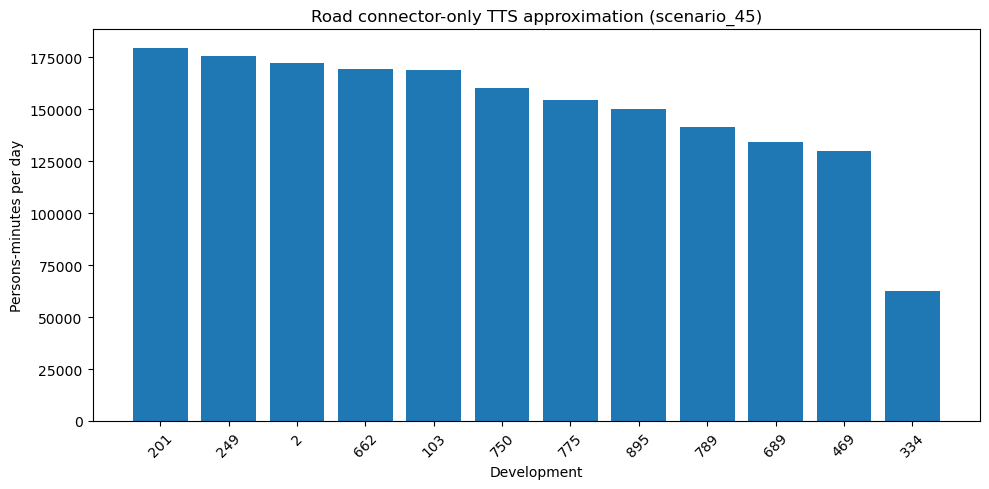

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib

# Work around the matplotlib/IPython mismatch in infraScan2.
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

LOCAL_PATH = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs/local_accessibility.csv')
TT_PATH = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs/traveltime_savings_od.csv')
TOTAL_PATH = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs/total_costs_od.csv')
OLD_TOTAL_PATH = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs/generatedByMe/total_costs.csv')

VTTS_H = 32.2
TRIP_GENERATION_DAY_CELL = 1.14
DURATION_YEARS = 50
SCEN = 'scenario_45'
CURRENT_DEVS = [2, 103, 201, 249, 334, 469, 662, 689, 750, 775, 789, 895]

local_df = pd.read_csv(LOCAL_PATH)
tt_df = pd.read_csv(TT_PATH)
total_df = pd.read_csv(TOTAL_PATH)
old_total_df = pd.read_csv(OLD_TOTAL_PATH)

local_col = f'local_{SCEN}'
tt_col = f'tt_{SCEN}'
total_col = f'total_{SCEN}'

connector_tts = local_df.loc[local_df['ID_develop'].isin(CURRENT_DEVS), ['ID_develop', local_col]].copy()
connector_tts = connector_tts.rename(columns={'ID_develop': 'development', local_col: 'connector_benefit_chf'})

# Convert CHF back to minutes.
connector_tts['connector_minutes_total_horizon'] = connector_tts['connector_benefit_chf'] / (VTTS_H / 60.0)
connector_tts['connector_minutes_per_day'] = connector_tts['connector_benefit_chf'] / (
    (VTTS_H / 60.0) * TRIP_GENERATION_DAY_CELL * 365 * DURATION_YEARS
)

cost_compare = total_df[['ID_new', total_col]].rename(columns={'ID_new': 'development', total_col: 'current_total_chf'})
cost_compare = cost_compare.merge(
    tt_df[['development', tt_col]].rename(columns={tt_col: 'current_tt_chf'}),
    on='development', how='left'
)
cost_compare = cost_compare.merge(
    connector_tts[['development', 'connector_benefit_chf', 'connector_minutes_per_day']],
    on='development', how='left'
)
cost_compare = cost_compare.merge(
    old_total_df[['ID_new', 'total_medium']].rename(columns={'ID_new': 'development', 'total_medium': 'old_total_medium_chf'}),
    on='development', how='left'
)

cost_compare = cost_compare[cost_compare['development'].isin(CURRENT_DEVS)].copy()
# If we remove the problematic TT block, totals increase by subtracting the current TT term.
cost_compare['adjusted_total_no_tt_chf'] = cost_compare['current_total_chf'] - cost_compare['current_tt_chf']
cost_compare['delta_adjusted_vs_current_chf'] = cost_compare['adjusted_total_no_tt_chf'] - cost_compare['current_total_chf']
cost_compare['delta_adjusted_vs_old_medium_chf'] = cost_compare['adjusted_total_no_tt_chf'] - cost_compare['old_total_medium_chf']

cost_compare = cost_compare.sort_values('connector_minutes_per_day', ascending=False).reset_index(drop=True)

summary = pd.DataFrame([
    {
        'scenario': SCEN,
        'n_developments': len(cost_compare),
        'mean_connector_minutes_per_day': cost_compare['connector_minutes_per_day'].mean(),
        'median_connector_minutes_per_day': cost_compare['connector_minutes_per_day'].median(),
        'mean_current_total_mio_chf': cost_compare['current_total_chf'].mean() / 1e6,
        'mean_adjusted_total_no_tt_mio_chf': cost_compare['adjusted_total_no_tt_chf'].mean() / 1e6,
        'mean_old_total_medium_mio_chf': cost_compare['old_total_medium_chf'].mean() / 1e6,
    }
])

display(summary)
display(cost_compare[['development', 'connector_benefit_chf', 'connector_minutes_per_day', 'current_tt_chf', 'current_total_chf', 'adjusted_total_no_tt_chf', 'old_total_medium_chf', 'delta_adjusted_vs_old_medium_chf']])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cost_compare['development'].astype(str), cost_compare['connector_minutes_per_day'])
ax.set_title(f'Road connector-only TTS approximation ({SCEN})')
ax.set_xlabel('Development')
ax.set_ylabel('Persons-minutes per day')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

DEVS = [2, 103, 201, 249, 334, 469, 662, 689, 750, 775, 789, 895]
BASE_COSTS = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')
BASE_FLOW = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/traffic_flow/developments/tt_i')

# Current data
agg_tt = pd.read_csv(BASE_COSTS / 'traveltime_savings_aggregate.csv')
od_tt = pd.read_csv(BASE_COSTS / 'traveltime_savings_od.csv')
local_cur = pd.read_csv(BASE_COSTS / 'local_accessibility.csv')

# Old data
old_base = BASE_COSTS / 'Marggi-10scen'
old_tt = pd.read_csv(old_base / 'traveltime_savings.csv')
old_local = pd.read_csv(old_base / 'local_accessibility.csv')

# New-link raw time from aggregate link TT output
rows = []
for scen in ['scenario_28', 'scenario_45', 'scenario_94']:
    for dev in DEVS:
        arr = pd.read_csv(BASE_FLOW / f'intTrec_i_{dev}_{scen}.csv', header=None)[0].to_numpy()
        rows.append({'development': dev, 'scenario': scen, 'new_link_tt_min': float(arr[-1]) * 60.0})
new_link_df = pd.DataFrame(rows)

records = []
for scen in ['28', '45', '94']:
    local_col = f'local_scenario_{scen}'
    tt_agg_col = f'tt_scenario_{scen}'
    tt_od_col = f'tt_scenario_{scen}'

    cur_local = local_cur[['ID_develop', local_col]].rename(columns={'ID_develop': 'development', local_col: 'local_chf'})
    cur_agg = agg_tt[['development', tt_agg_col]].rename(columns={tt_agg_col: 'tt_chf'})
    cur_od = od_tt[['development', tt_od_col]].rename(columns={tt_od_col: 'tt_chf'})
    link = new_link_df[new_link_df['scenario'] == f'scenario_{scen}'][['development', 'new_link_tt_min']]

    df_agg = cur_agg.merge(cur_local, on='development').merge(link, on='development')
    df_agg = df_agg[df_agg['development'].isin(DEVS)].copy()
    df_agg['dataset'] = f'current_aggregate_{scen}'
    records.append(df_agg)

    df_od = cur_od.merge(cur_local, on='development').merge(link, on='development')
    df_od = df_od[df_od['development'].isin(DEVS)].copy()
    df_od['dataset'] = f'current_od_{scen}'
    records.append(df_od)

# Old Marggi s2 + medium new-link times as rough reference
old_link_rows = []
for dev in DEVS:
    arr = pd.read_csv(BASE_FLOW / f'intTrec_i_{dev}_medium.csv', header=None)[0].to_numpy()
    old_link_rows.append({'development': dev, 'new_link_tt_min': float(arr[-1]) * 60.0})
old_link = pd.DataFrame(old_link_rows)
old_df = old_tt[['development', 'tt_2']].rename(columns={'tt_2': 'tt_chf'})
old_df = old_df.merge(old_local[['ID_develop', 'local_s2']].rename(columns={'ID_develop': 'development', 'local_s2': 'local_chf'}), on='development')
old_df = old_df.merge(old_link, on='development')
old_df = old_df[old_df['development'].isin(DEVS)].copy()
old_df['dataset'] = 'old_marggi_s2'
records.append(old_df)

compare = pd.concat(records, ignore_index=True)

# Correlation summary
corr_rows = []
for dataset, grp in compare.groupby('dataset'):
    corr_rows.append({
        'dataset': dataset,
        'n': len(grp),
        'corr_tt_local': grp['tt_chf'].corr(grp['local_chf']),
        'corr_tt_new_link_min': grp['tt_chf'].corr(grp['new_link_tt_min']),
        'mean_tt_mio': grp['tt_chf'].mean() / 1e6,
        'mean_local_mio': grp['local_chf'].mean() / 1e6,
        'mean_new_link_min': grp['new_link_tt_min'].mean(),
    })

corr_df = pd.DataFrame(corr_rows).sort_values('dataset').reset_index(drop=True)
display(corr_df)

# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plot_sets = ['current_aggregate_45', 'current_od_45', 'current_aggregate_94', 'old_marggi_s2']
for ax, dataset in zip(axes, plot_sets):
    grp = compare[compare['dataset'] == dataset].copy()
    ax.scatter(grp['local_chf'] / 1e6, grp['tt_chf'] / 1e6)
    for _, row in grp.iterrows():
        ax.annotate(str(int(row['development'])), (row['local_chf'] / 1e6, row['tt_chf'] / 1e6), fontsize=8)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'{dataset}: TT vs local')
    ax.set_xlabel('Local accessibility [Mio CHF]')
    ax.set_ylabel('TT [Mio CHF]')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, dataset in zip(axes, plot_sets):
    grp = compare[compare['dataset'] == dataset].copy()
    ax.scatter(grp['new_link_tt_min'], grp['tt_chf'] / 1e6)
    for _, row in grp.iterrows():
        ax.annotate(str(int(row['development'])), (row['new_link_tt_min'], row['tt_chf'] / 1e6), fontsize=8)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'{dataset}: TT vs new-link time')
    ax.set_xlabel('New-link travel time [min]')
    ax.set_ylabel('TT [Mio CHF]')
plt.tight_layout()
plt.show()

# Simple combined table for scenario 45 and old reference
focus = compare[compare['dataset'].isin(['current_aggregate_45', 'current_od_45', 'old_marggi_s2'])].copy()
display(focus.sort_values(['dataset', 'development']).reset_index(drop=True))


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

DEVS = [2, 103, 201, 249, 334, 469, 662, 689, 750, 775, 789, 895]
FLOW_BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/traffic_flow/developments')
COST_BASE = Path('/Volumes/WD_Windows/MSc_Thesis/data/infraScanRoad/costs')
SCEN = 'scenario_45'
OLD_SCEN = 'medium'

# Build current aggregate decomposition
sq_tt = pd.read_csv(FLOW_BASE / 'tt_i' / f'intTrec_i_status_quo_{SCEN}.csv', header=None)[0].to_numpy()
sq_flow = pd.read_csv(FLOW_BASE / 'D_i' / f'Xi_sum_status_quo_{SCEN}.csv', header=None)[0].to_numpy()
rows = []
for dev in DEVS:
    dev_tt = pd.read_csv(FLOW_BASE / 'tt_i' / f'intTrec_i_{dev}_{SCEN}.csv', header=None)[0].to_numpy()
    dev_flow = pd.read_csv(FLOW_BASE / 'D_i' / f'Xi_sum_{dev}_{SCEN}.csv', header=None)[0].to_numpy()
    common_n = min(len(sq_tt), len(dev_tt), len(sq_flow), len(dev_flow))
    sq_common_devflow = float(np.dot(sq_tt[:common_n], dev_flow[:common_n]))
    dev_common_devflow = float(np.dot(dev_tt[:common_n], dev_flow[:common_n]))
    new_link_dev = float(np.dot(dev_tt[common_n:], dev_flow[common_n:]))
    rows.append({
        'development': dev,
        'common_network_diff_on_dev_flow': sq_common_devflow - dev_common_devflow,
        'dev_new_link_tt': new_link_dev,
    })
current_link_df = pd.DataFrame(rows)

# Build old aggregate decomposition
sq_tt_old = pd.read_csv(FLOW_BASE / 'tt_i' / f'intTrec_i_status_quo_{OLD_SCEN}.csv', header=None)[0].to_numpy()
sq_flow_old = pd.read_csv(FLOW_BASE / 'D_i' / f'Xi_sum_status_quo_{OLD_SCEN}.csv', header=None)[0].to_numpy()
rows = []
for dev in DEVS:
    dev_tt = pd.read_csv(FLOW_BASE / 'tt_i' / f'intTrec_i_{dev}_{OLD_SCEN}.csv', header=None)[0].to_numpy()
    dev_flow = pd.read_csv(FLOW_BASE / 'D_i' / f'Xi_sum_{dev}_{OLD_SCEN}.csv', header=None)[0].to_numpy()
    common_n = min(len(sq_tt_old), len(dev_tt), len(sq_flow_old), len(dev_flow))
    sq_common_devflow = float(np.dot(sq_tt_old[:common_n], dev_flow[:common_n]))
    dev_common_devflow = float(np.dot(dev_tt[:common_n], dev_flow[:common_n]))
    new_link_dev = float(np.dot(dev_tt[common_n:], dev_flow[common_n:]))
    rows.append({
        'development': dev,
        'common_network_diff_on_dev_flow': sq_common_devflow - dev_common_devflow,
        'dev_new_link_tt': new_link_dev,
    })
old_link_df = pd.DataFrame(rows)

# Monetized component comparison
agg_tt = pd.read_csv(COST_BASE / 'traveltime_savings_aggregate.csv')[['development', 'tt_scenario_45']].rename(columns={'tt_scenario_45': 'tt_chf'})
local = pd.read_csv(COST_BASE / 'local_accessibility.csv')[['ID_develop', 'local_scenario_45']].rename(columns={'ID_develop': 'development', 'local_scenario_45': 'local_chf'})
total = pd.read_csv(COST_BASE / 'total_costs_aggregate.csv')[['ID_new', 'total_scenario_45']].rename(columns={'ID_new': 'development', 'total_scenario_45': 'total_chf'})
comp = total.merge(agg_tt, on='development').merge(local, on='development')
comp = comp[comp['development'].isin(DEVS)].copy()
comp['adjusted_no_tt_chf'] = comp['total_chf'] - comp['tt_chf']
comp = comp.sort_values('development').reset_index(drop=True)

# Plot 1: link decomposition current vs old
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, df, title in [
    (axes[0], current_link_df, 'Current aggregate link decomposition (scenario_45)'),
    (axes[1], old_link_df, 'Old aggregate link decomposition (medium)'),
]:
    x = np.arange(len(df))
    w = 0.38
    ax.bar(x - w/2, df['common_network_diff_on_dev_flow'], width=w, label='Common-link diff')
    ax.bar(x + w/2, df['dev_new_link_tt'], width=w, label='New-link TT contribution')
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(df['development'].astype(str), rotation=45)
    ax.set_title(title)
    ax.set_xlabel('Development')
    ax.set_ylabel('Weighted link-TT units')
axes[0].legend()
plt.tight_layout()
plt.show()

# Plot 2: local vs negative tt on the monetary side
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = comp.copy()
plot_df['neg_tt_chf'] = -plot_df['tt_chf']
x = np.arange(len(plot_df))
w = 0.38
ax.bar(x - w/2, plot_df['local_chf'] / 1e6, width=w, label='Local accessibility', color='tab:blue')
ax.bar(x + w/2, plot_df['neg_tt_chf'] / 1e6, width=w, label='-TT (size of negative TT block)', color='tab:orange')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['development'].astype(str), rotation=45)
ax.set_title('Current aggregate scenario_45: local benefit versus magnitude of negative TT')
ax.set_xlabel('Development')
ax.set_ylabel('Mio CHF')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: total current vs adjusted no-tt
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, plot_df['total_chf'] / 1e6, width=w, label='Current aggregate total', color='tab:gray')
ax.bar(x + w/2, plot_df['adjusted_no_tt_chf'] / 1e6, width=w, label='Aggregate total without TT', color='tab:green')
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['development'].astype(str), rotation=45)
ax.set_title('Current aggregate scenario_45: effect of removing TT block')
ax.set_xlabel('Development')
ax.set_ylabel('Mio CHF')
ax.legend()
plt.tight_layout()
plt.show()

# Print compact tables too
print('Current link decomposition')
display(current_link_df)
print('Old link decomposition')
display(old_link_df)
print('Current monetary decomposition')
display(comp[['development', 'local_chf', 'tt_chf', 'total_chf', 'adjusted_no_tt_chf']])


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize

ROOT = Path('/Users/laura/Desktop/infraScan_lkuehner')
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from infraScan.infraScanRoad.scoring import GetHighwayPHDemandPerCommune, GetODMatrix

DATA = Path('/Volumes/WD_Windows/MSc_Thesis')
SCEN = 'scenario_45'
DEV = 334
VTTS_H = 32.2
DURATION_YEARS = 50

# 1. Load status-quo and development access-time rasters (seconds to nearest access point)
with rasterio.open(DATA / 'data/infraScanRoad/Network/travel_time/travel_time_raster.tif') as src:
    sq_tt = src.read(1).astype(float)
    transform = src.transform
    shape = (src.height, src.width)

with rasterio.open(DATA / f'data/infraScanRoad/Network/travel_time/developments/dev{DEV}_travel_time_raster.tif') as src:
    dev_tt = src.read(1).astype(float)

with rasterio.open(DATA / f'data/infraScanRoad/Network/travel_time/developments/dev{DEV}_source_id_raster.tif') as src:
    dev_source_id = src.read(1)

# 2. Cell-wise time saving in seconds.
delta_sec = sq_tt - dev_tt
affected_mask = dev_source_id == 9999

print('Affected cells routed via the new access point:', int(affected_mask.sum()))
print('Mean saving on affected cells [min]:', float(np.nanmean(delta_sec[affected_mask]) / 60.0))
print('Median saving on affected cells [min]:', float(np.nanmedian(delta_sec[affected_mask]) / 60.0))
print('Max saving on affected cells [min]:', float(np.nanmax(delta_sec[affected_mask]) / 60.0))

# 3. Build commune raster on the same grid and load scenario population raster.
communes = gpd.read_file(DATA / 'data/_basic_data/Gemeindegrenzen/UP_GEMEINDEN_F.shp').to_crs('EPSG:2056')
commune_raster = rasterize(
    ((geom, int(bfs)) for geom, bfs in zip(communes.geometry, communes['BFS'])),
    out_shape=shape,
    transform=transform,
    fill=0,
    dtype='int32',
)

with rasterio.open(DATA / f'data/independent_variable/processed/scenario/{SCEN}_pop.tif') as src:
    pop = src.read(1).astype(float)

# 4. Fixed commune OD matrix.
import os
os.chdir(DATA)
od = GetHighwayPHDemandPerCommune()
odmat = GetODMatrix(od).astype(float)
productions = odmat.sum(axis=1).rename('productions')
attractions = odmat.sum(axis=0).rename('attractions')
productions.index = pd.to_numeric(productions.index)
attractions.index = pd.to_numeric(attractions.index)

# 5. Commune-level expected access savings (population-weighted within each commune).
rows = []
for bfs in np.unique(commune_raster):
    if bfs <= 0:
        continue
    cmask = commune_raster == bfs
    pop_mass = float(np.nansum(pop[cmask]))
    if pop_mass <= 0:
        continue

    weighted_delta_sec = float(np.nansum(delta_sec[cmask] * pop[cmask]) / pop_mass)
    affected_pop_share = float(np.nansum(pop[cmask & affected_mask]) / pop_mass)

    rows.append({
        'BFS': int(bfs),
        'pop_mass': pop_mass,
        'weighted_delta_sec': weighted_delta_sec,
        'affected_pop_share': affected_pop_share,
    })

comm_df = pd.DataFrame(rows)
comm_df = comm_df.merge(productions, left_on='BFS', right_index=True, how='left')
comm_df = comm_df.merge(attractions, left_on='BFS', right_index=True, how='left')
comm_df[['productions', 'attractions']] = comm_df[['productions', 'attractions']].fillna(0.0)

# 6. Weight on a fixed OD basis.
# Origin-side contribution: origins in commune c become faster by expected_delta(c)
# Destination-side contribution: destinations in commune c become faster by expected_delta(c)
origin_sec_day = float((comm_df['weighted_delta_sec'] * comm_df['productions']).sum())
dest_sec_day = float((comm_df['weighted_delta_sec'] * comm_df['attractions']).sum())
total_min_day = (origin_sec_day + dest_sec_day) / 60.0

# 7. Monetize over the appraisal horizon.
monetized_chf = total_min_day * (VTTS_H / 60.0) * 365.0 * DURATION_YEARS

summary = pd.DataFrame([
    {
        'development': DEV,
        'scenario': SCEN,
        'affected_cells': int(affected_mask.sum()),
        'mean_delta_affected_min': float(np.nanmean(delta_sec[affected_mask]) / 60.0),
        'median_delta_affected_min': float(np.nanmedian(delta_sec[affected_mask]) / 60.0),
        'weighted_minutes_per_day_origin_dest': total_min_day,
        'monetized_chf_365x50': monetized_chf,
    }
])

display(summary)
print('Top communes by origin-side contribution [persons-min/day]')
comm_df['origin_min_day'] = comm_df['weighted_delta_sec'] * comm_df['productions'] / 60.0
display(comm_df.sort_values('origin_min_day', ascending=False).head(15))



## Final Road TTS Definition And Corrected Total Benefits

For the current road project type (new access / connector links), use the following working definition:

1. Compute a **connector/access-based time difference on a fixed OD basis**.
   - Use the cell-wise travel-time difference between the status-quo access raster and the development access raster.
   - Aggregate the cell differences to communes using the **generated scenario population raster**.
   - Weight the commune-level time differences with the fixed commune OD matrix.
   - Include both **origin-side access** and **destination-side egress** contributions.

2. Monetize with the **existing road TTS formula**:

`monetized_TTS = weighted_person_minutes_peak_hour * (VTTS / 60) * 2.5 * 250 * duration`

3. Do **not** use the old `local accessibility` CHF value directly as the TTS measure.

4. For the current connector-type projects, replace **both** old travel-time blocks with the new connector-based TTS:

`new_total_benefit = old_total_benefit - old_tt_block - old_local_accessibility_block + new_connector_tts`

5. Verification target:
   - all positive raster savings should occur on cells that switch to the new access point
   - outside the new-access catchment, the mean time difference should be approximately zero.


In [2]:
from pathlib import Path
import sys
import re
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize

ROOT = Path('/Users/laura/Desktop/infraScan_lkuehner')
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from infraScan.infraScanRoad.scoring import GetHighwayPHDemandPerCommune, GetODMatrix

DATA = Path('/Volumes/WD_Windows/MSc_Thesis')
SCENARIOS = ['scenario_28', 'scenario_45', 'scenario_94']
VTTS_H = 32.2
DURATION_YEARS = 50

with rasterio.open(DATA / 'data/infraScanRoad/Network/travel_time/travel_time_raster.tif') as src:
    sq_tt = src.read(1).astype(float)
    transform = src.transform
    shape = (src.height, src.width)

communes = gpd.read_file(DATA / 'data/_basic_data/Gemeindegrenzen/UP_GEMEINDEN_F.shp').to_crs('EPSG:2056')
commune_raster = rasterize(
    ((geom, int(bfs)) for geom, bfs in zip(communes.geometry, communes['BFS'])),
    out_shape=shape,
    transform=transform,
    fill=0,
    dtype='int32',
)

os.chdir(DATA)
od = GetHighwayPHDemandPerCommune()
odmat = GetODMatrix(od).astype(float)
productions = odmat.sum(axis=1).rename('productions')
attractions = odmat.sum(axis=0).rename('attractions')
productions.index = pd.to_numeric(productions.index)
attractions.index = pd.to_numeric(attractions.index)

cost_base = DATA / 'data/infraScanRoad/costs'
od_total_df = pd.read_csv(cost_base / 'total_costs_od.csv')
agg_total_df = pd.read_csv(cost_base / 'total_costs_aggregate.csv')
od_tt_df = pd.read_csv(cost_base / 'traveltime_savings_od.csv')
agg_tt_df = pd.read_csv(cost_base / 'traveltime_savings_aggregate.csv')
local_df = pd.read_csv(cost_base / 'local_accessibility.csv')

summary_rows = []
verify_rows = []
detail_tables = {}

for SCEN in SCENARIOS:
    with rasterio.open(DATA / f'data/independent_variable/processed/scenario/{SCEN}_pop.tif') as src:
        pop = src.read(1).astype(float)

    base_rows = []
    for bfs in np.unique(commune_raster):
        if bfs <= 0:
            continue
        cmask = commune_raster == bfs
        pop_mass = float(np.nansum(pop[cmask]))
        if pop_mass <= 0:
            continue
        base_rows.append({'BFS': int(bfs), 'pop_mass': pop_mass})

    base_comm = pd.DataFrame(base_rows)
    base_comm = base_comm.merge(productions, left_on='BFS', right_index=True, how='left')
    base_comm = base_comm.merge(attractions, left_on='BFS', right_index=True, how='left')
    base_comm[['productions', 'attractions']] = base_comm[['productions', 'attractions']].fillna(0.0)

    tt_dir = DATA / 'data/infraScanRoad/traffic_flow/developments/tt_i'
    pattern = re.compile(rf'intTrec_i_(\d+)_{re.escape(SCEN)}\.csv$')
    devs = sorted(int(m.group(1)) for p in tt_dir.iterdir() if (m := pattern.match(p.name)))

    rows = []
    verify = []
    for dev in devs:
        with rasterio.open(DATA / f'data/infraScanRoad/Network/travel_time/developments/dev{dev}_travel_time_raster.tif') as src:
            dev_tt = src.read(1).astype(float)
        with rasterio.open(DATA / f'data/infraScanRoad/Network/travel_time/developments/dev{dev}_source_id_raster.tif') as src:
            dev_source_id = src.read(1)

        delta_sec = sq_tt - dev_tt
        affected_mask = dev_source_id == 9999
        improved_mask = delta_sec > 1e-9
        worsened_mask = delta_sec < -1e-9

        comm = base_comm.copy()
        weighted_delta = []
        for bfs, pop_mass in zip(comm['BFS'], comm['pop_mass']):
            cmask = commune_raster == bfs
            wd = float(np.nansum(delta_sec[cmask] * pop[cmask]) / pop_mass) if pop_mass > 0 else 0.0
            weighted_delta.append(wd)
        comm['weighted_delta_sec'] = weighted_delta

        origin_sec_peak = float((comm['weighted_delta_sec'] * comm['productions']).sum())
        dest_sec_peak = float((comm['weighted_delta_sec'] * comm['attractions']).sum())
        connector_person_minutes_peak_hour = (origin_sec_peak + dest_sec_peak) / 60.0
        connector_tts_chf = connector_person_minutes_peak_hour * (VTTS_H / 60.0) * 2.5 * 250 * DURATION_YEARS

        new_link_arr = pd.read_csv(
            DATA / f'data/infraScanRoad/traffic_flow/developments/tt_i/intTrec_i_{dev}_{SCEN}.csv',
            header=None,
        )[0].to_numpy()
        new_link_tt_min = float(new_link_arr[-1]) * 60.0

        improved_pop_total = float(np.nansum(pop[improved_mask]))
        improved_pop_on_9999 = float(np.nansum(pop[improved_mask & affected_mask]))
        worsened_pop_total = float(np.nansum(pop[worsened_mask]))
        worsened_pop_on_9999 = float(np.nansum(pop[worsened_mask & affected_mask]))
        mean_delta_affected_min = float(np.nanmean(delta_sec[affected_mask]) / 60.0)
        median_delta_affected_min = float(np.nanmedian(delta_sec[affected_mask]) / 60.0)

        rows.append({
            'development': dev,
            'connector_person_minutes_peak_hour': connector_person_minutes_peak_hour,
            'connector_tts_chf': connector_tts_chf,
            'new_link_tt_min': new_link_tt_min,
            'mean_delta_affected_min': mean_delta_affected_min,
            'median_delta_affected_min': median_delta_affected_min,
        })
        verify.append({
            'development': dev,
            'share_improved_pop_on_new_access': improved_pop_on_9999 / improved_pop_total if improved_pop_total > 0 else np.nan,
            'share_worsened_pop_on_new_access': worsened_pop_on_9999 / worsened_pop_total if worsened_pop_total > 0 else np.nan,
            'mean_delta_affected_min': mean_delta_affected_min,
            'median_delta_affected_min': median_delta_affected_min,
            'mean_delta_outside_new_access_min': float(np.nanmean(delta_sec[~affected_mask]) / 60.0),
        })

    connector = pd.DataFrame(rows)
    verify_df = pd.DataFrame(verify)
    od_total = od_total_df[['ID_new', f'total_{SCEN}']].rename(columns={'ID_new': 'development', f'total_{SCEN}': 'od_total_chf'})
    agg_total = agg_total_df[['ID_new', f'total_{SCEN}']].rename(columns={'ID_new': 'development', f'total_{SCEN}': 'agg_total_chf'})
    od_tt = od_tt_df[['development', f'tt_{SCEN}']].rename(columns={f'tt_{SCEN}': 'od_tt_chf'})
    agg_tt = agg_tt_df[['development', f'tt_{SCEN}']].rename(columns={f'tt_{SCEN}': 'agg_tt_chf'})
    local = local_df[['ID_develop', f'local_{SCEN}']].rename(columns={'ID_develop': 'development', f'local_{SCEN}': 'local_chf'})

    final = connector.merge(od_total, on='development').merge(agg_total, on='development').merge(od_tt, on='development').merge(agg_tt, on='development').merge(local, on='development')
    final['od_total_connector_only'] = final['od_total_chf'] - final['od_tt_chf'] - final['local_chf'] + final['connector_tts_chf']
    final['agg_total_connector_only'] = final['agg_total_chf'] - final['agg_tt_chf'] - final['local_chf'] + final['connector_tts_chf']

    # Comparison variant requested: keep local block, replace TT block only.
    final['od_total_minus_tt_plus_connector'] = final['od_total_chf'] - final['od_tt_chf'] + final['connector_tts_chf']
    final['agg_total_minus_tt_plus_connector'] = final['agg_total_chf'] - final['agg_tt_chf'] + final['connector_tts_chf']

    summary_rows.append({
        'scenario': SCEN,
        'mean_connector_tts_mio_chf': final['connector_tts_chf'].mean() / 1e6,
        'mean_od_total_connector_only_mio_chf': final['od_total_connector_only'].mean() / 1e6,
        'mean_agg_total_connector_only_mio_chf': final['agg_total_connector_only'].mean() / 1e6,
        'positive_od_connector_only': int((final['od_total_connector_only'] > 0).sum()),
        'positive_agg_connector_only': int((final['agg_total_connector_only'] > 0).sum()),
        'mean_od_total_minus_tt_plus_connector_mio_chf': final['od_total_minus_tt_plus_connector'].mean() / 1e6,
        'mean_agg_total_minus_tt_plus_connector_mio_chf': final['agg_total_minus_tt_plus_connector'].mean() / 1e6,
        'positive_od_minus_tt_plus_connector': int((final['od_total_minus_tt_plus_connector'] > 0).sum()),
        'positive_agg_minus_tt_plus_connector': int((final['agg_total_minus_tt_plus_connector'] > 0).sum()),
    })
    verify_rows.append({
        'scenario': SCEN,
        'mean_share_improved_pop_on_new_access': verify_df['share_improved_pop_on_new_access'].mean(),
        'mean_share_worsened_pop_on_new_access': verify_df['share_worsened_pop_on_new_access'].mean(),
        'mean_delta_affected_min': verify_df['mean_delta_affected_min'].mean(),
        'median_delta_affected_min': verify_df['median_delta_affected_min'].mean(),
        'mean_delta_outside_new_access_min': verify_df['mean_delta_outside_new_access_min'].mean(),
    })

    detail_tables[SCEN] = final[[
        'development',
        'connector_person_minutes_peak_hour',
        'connector_tts_chf',
        'mean_delta_affected_min',
        'median_delta_affected_min',
        'local_chf',
        'new_link_tt_min',
        'od_total_connector_only',
        'agg_total_connector_only',
        'od_total_minus_tt_plus_connector',
        'agg_total_minus_tt_plus_connector',
    ]].sort_values('development').reset_index(drop=True)

summary = pd.DataFrame(summary_rows)
verification = pd.DataFrame(verify_rows)

display(summary)
display(verification)
for scen in SCENARIOS:
    print(f'\n{scen}')
    display(detail_tables[scen])

/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1054: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD['wert'].loc[(communalOD['quelle_code'] == communalOD['ziel_code'])] = 0
/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRoad/scoring.py:1061: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  communalOD.loc[:, 'wert'] = communalOD['wert'] * tau


,scenario,mean_connector_tts_mio_chf,mean_od_total_connector_only_mio_chf,mean_agg_total_connector_only_mio_chf,positive_od_connector_only,positive_agg_connector_only,mean_od_total_minus_tt_plus_connector_mio_chf,mean_agg_total_minus_tt_plus_connector_mio_chf,positive_od_minus_tt_plus_connector,positive_agg_minus_tt_plus_connector
0,scenario_28,63.956126,-1165.969795,-1165.969795,0,0,-33.613101,-33.613101,8,8
1,scenario_45,63.955724,-1165.970197,-1165.970197,0,0,508.698931,508.698931,11,11
2,scenario_94,63.955523,-1165.970399,-1165.970399,0,0,1016.434300,1016.434300,11,11


,scenario,mean_share_improved_pop_on_new_access,mean_share_worsened_pop_on_new_access,mean_delta_affected_min,median_delta_affected_min,mean_delta_outside_new_access_min
0,scenario_28,1.0,NaN,3.399923,3.262779,0.0
1,scenario_45,1.0,NaN,3.399923,3.262779,0.0
2,scenario_94,1.0,NaN,3.399923,3.262779,0.0



scenario_28


,development,connector_person_minutes_peak_hour,connector_tts_chf,mean_delta_affected_min,median_delta_affected_min,local_chf,new_link_tt_min,od_total_connector_only,agg_total_connector_only,od_total_minus_tt_plus_connector,agg_total_minus_tt_plus_connector
0,2,4688.224090,7.862542e+07,3.373263,3.540709,1.299315e+09,4.954437,-7.020235e+08,-7.020235e+08,5.972917e+08,5.972917e+08
1,103,4483.763366,7.519645e+07,3.531070,3.421814,1.275520e+09,5.850766,-8.432159e+08,-8.432159e+08,4.323042e+08,4.323042e+08
2,201,4109.336791,6.891700e+07,4.166613,3.867565,1.356595e+09,9.009839,-1.300917e+09,-1.300917e+09,5.567794e+07,5.567794e+07
3,249,4128.583617,6.923979e+07,4.175784,3.809395,1.328340e+09,8.092883,-1.050525e+09,-1.050525e+09,2.778143e+08,2.778143e+08
4,334,1758.899721,2.949821e+07,1.068494,0.670979,4.724776e+08,3.322171,-6.117695e+08,-6.117695e+08,-1.392919e+08,-1.392919e+08
5,469,3792.176118,6.359795e+07,2.459589,3.059411,9.801768e+08,3.556873,-6.220257e+08,-6.220257e+08,3.581511e+08,3.581511e+08
6,662,4169.008595,6.991775e+07,4.629817,4.206877,1.282028e+09,9.357661,-1.143128e+09,-1.143128e+09,1.389000e+08,1.389000e+08
7,689,3399.788918,5.701729e+07,3.394190,3.288280,1.012132e+09,6.519218,-3.422472e+09,-3.422472e+09,-2.410340e+09,-2.410340e+09
8,750,3946.895708,6.619273e+07,3.859857,3.613508,1.211142e+09,6.778598,-1.251488e+09,-1.251488e+09,-4.034641e+07,-4.034641e+07
9,775,3470.199403,5.819814e+07,4.258439,4.138535,1.168909e+09,10.178163,-9.918223e+08,-9.918223e+08,1.770871e+08,1.770871e+08



scenario_45


,development,connector_person_minutes_peak_hour,connector_tts_chf,mean_delta_affected_min,median_delta_affected_min,local_chf,new_link_tt_min,od_total_connector_only,agg_total_connector_only,od_total_minus_tt_plus_connector,agg_total_minus_tt_plus_connector
0,2,4688.224089,7.862542e+07,3.373263,3.540709,1.923234e+09,4.954437,-7.020235e+08,-7.020235e+08,1.221210e+09,1.221210e+09
1,103,4483.763365,7.519645e+07,3.531070,3.421814,1.887723e+09,5.850766,-8.432159e+08,-8.432159e+08,1.044507e+09,1.044507e+09
2,201,4109.336792,6.891700e+07,4.166613,3.867565,2.004157e+09,9.009839,-1.300917e+09,-1.300917e+09,7.032404e+08,7.032404e+08
3,249,4128.583618,6.923979e+07,4.175784,3.809395,1.962852e+09,8.092883,-1.050525e+09,-1.050525e+09,9.123272e+08,9.123272e+08
4,334,1758.611787,2.949339e+07,1.068494,0.670979,6.998071e+08,3.322171,-6.117743e+08,-6.117743e+08,8.803272e+07,8.803272e+07
5,469,3792.176118,6.359795e+07,2.459589,3.059411,1.451668e+09,3.556873,-6.220257e+08,-6.220257e+08,8.296420e+08,8.296420e+08
6,662,4169.008596,6.991775e+07,4.629817,4.206877,1.893742e+09,9.357661,-1.143128e+09,-1.143128e+09,7.506140e+08,7.506140e+08
7,689,3399.788918,5.701729e+07,3.394190,3.288280,1.497127e+09,6.519218,-3.422472e+09,-3.422472e+09,-1.925345e+09,-1.925345e+09
8,750,3946.895708,6.619273e+07,3.859857,3.613508,1.790737e+09,6.778598,-1.251488e+09,-1.251488e+09,5.392492e+08,5.392492e+08
9,775,3470.199405,5.819814e+07,4.258439,4.138535,1.726091e+09,10.178163,-9.918223e+08,-9.918223e+08,7.342690e+08,7.342690e+08



scenario_94


,development,connector_person_minutes_peak_hour,connector_tts_chf,mean_delta_affected_min,median_delta_affected_min,local_chf,new_link_tt_min,od_total_connector_only,agg_total_connector_only,od_total_minus_tt_plus_connector,agg_total_minus_tt_plus_connector
0,2,4688.224088,7.862542e+07,3.373263,3.540709,2.507374e+09,4.954437,-7.020235e+08,-7.020235e+08,1.805350e+09,1.805350e+09
1,103,4483.763363,7.519645e+07,3.531070,3.421814,2.460894e+09,5.850766,-8.432159e+08,-8.432159e+08,1.617678e+09,1.617678e+09
2,201,4109.336789,6.891700e+07,4.166613,3.867565,2.610424e+09,9.009839,-1.300917e+09,-1.300917e+09,1.309507e+09,1.309507e+09
3,249,4128.583615,6.923979e+07,4.175784,3.809395,2.556903e+09,8.092883,-1.050525e+09,-1.050525e+09,1.506378e+09,1.506378e+09
4,334,1758.467977,2.949097e+07,1.068494,0.670979,9.126680e+08,3.322171,-6.117767e+08,-6.117767e+08,3.008912e+08,3.008912e+08
5,469,3792.176117,6.359795e+07,2.459589,3.059411,1.893101e+09,3.556873,-6.220257e+08,-6.220257e+08,1.271075e+09,1.271075e+09
6,662,4169.008593,6.991775e+07,4.629817,4.206877,2.466452e+09,9.357661,-1.143128e+09,-1.143128e+09,1.323323e+09,1.323323e+09
7,689,3399.788915,5.701729e+07,3.394190,3.288280,1.951198e+09,6.519218,-3.422472e+09,-3.422472e+09,-1.471273e+09,-1.471273e+09
8,750,3946.895705,6.619273e+07,3.859857,3.613508,2.333375e+09,6.778598,-1.251488e+09,-1.251488e+09,1.081887e+09,1.081887e+09
9,775,3470.199403,5.819814e+07,4.258439,4.138535,2.247738e+09,10.178163,-9.918223e+08,-9.918223e+08,1.255916e+09,1.255916e+09


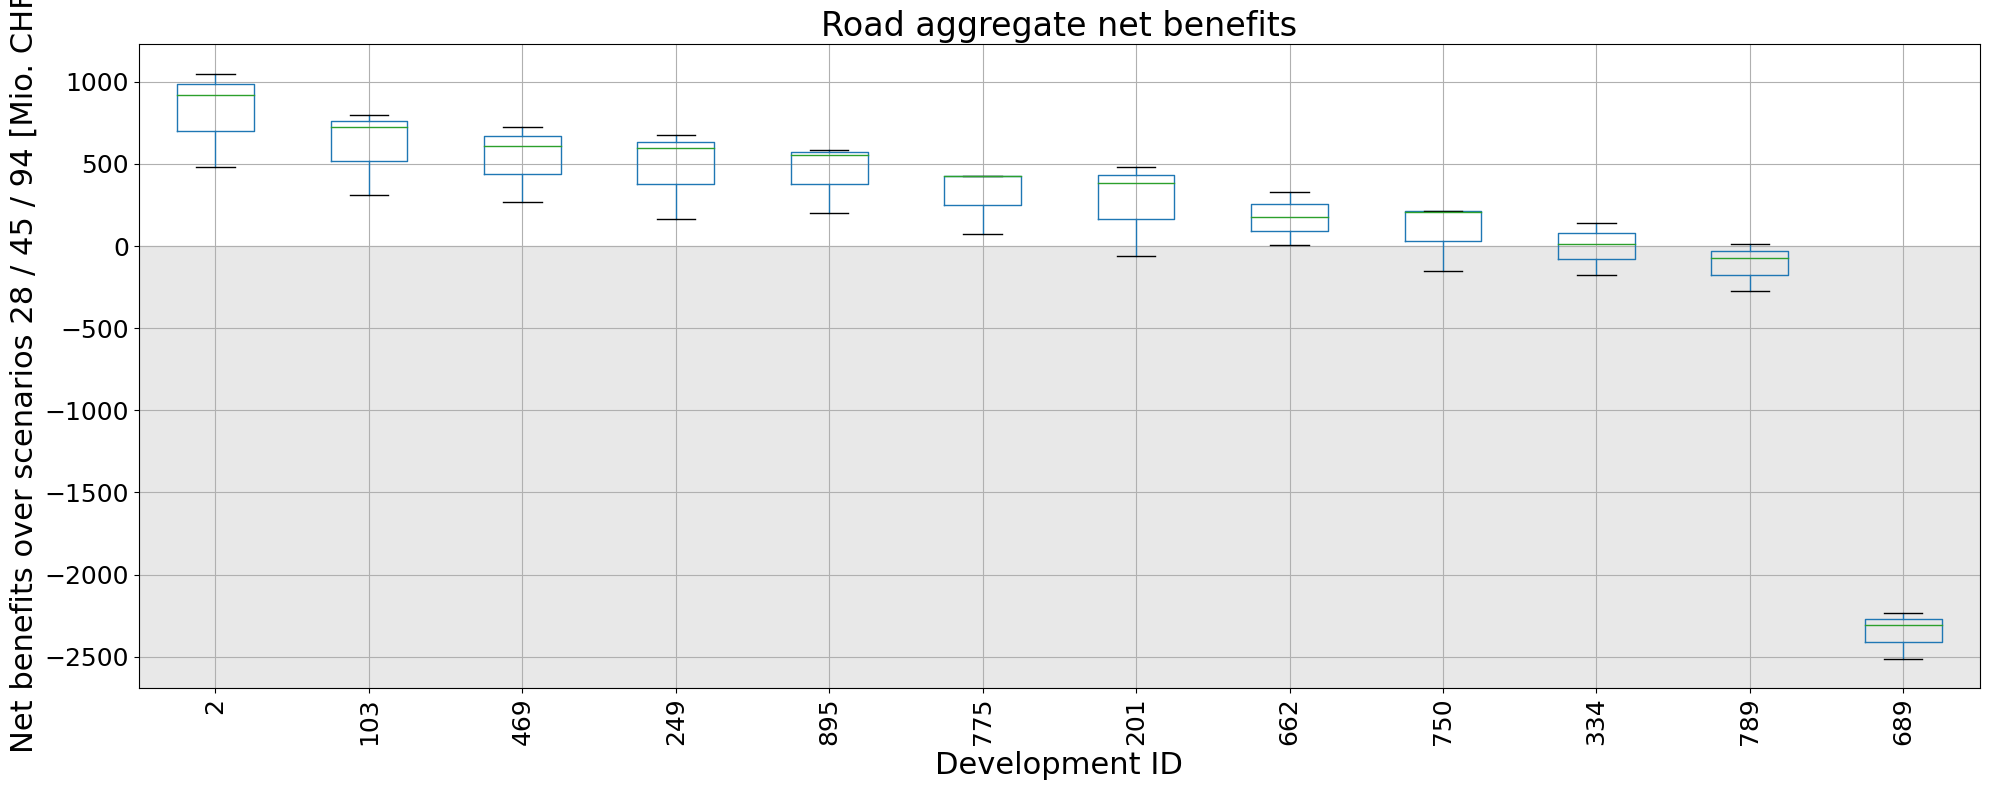

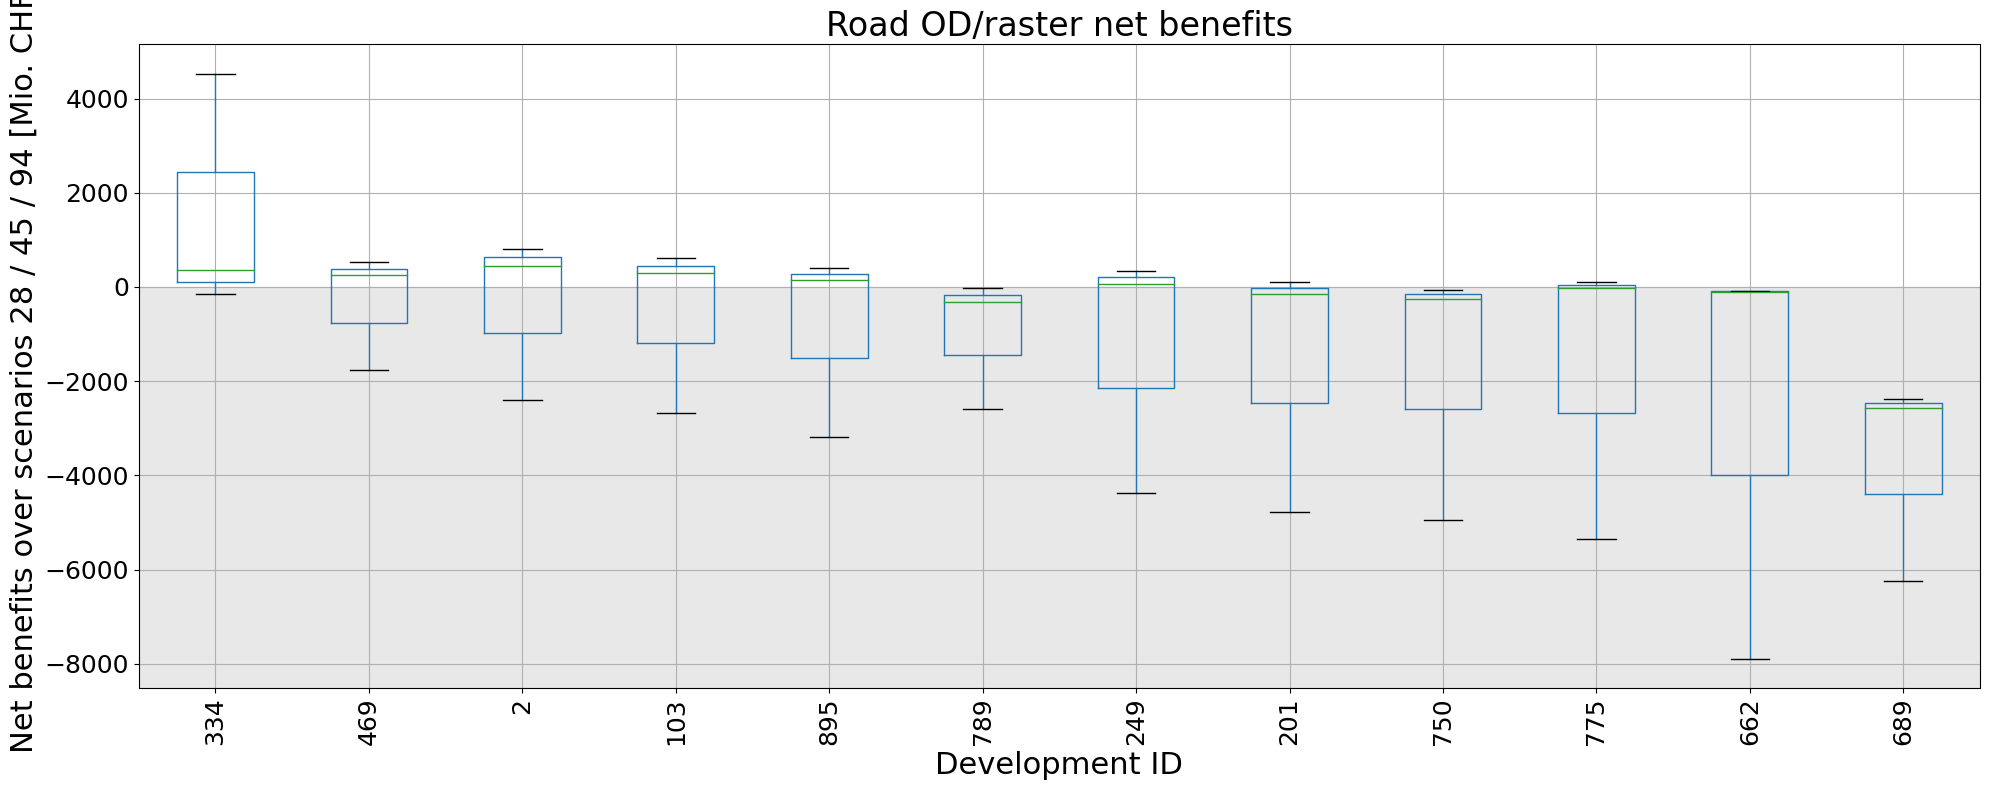

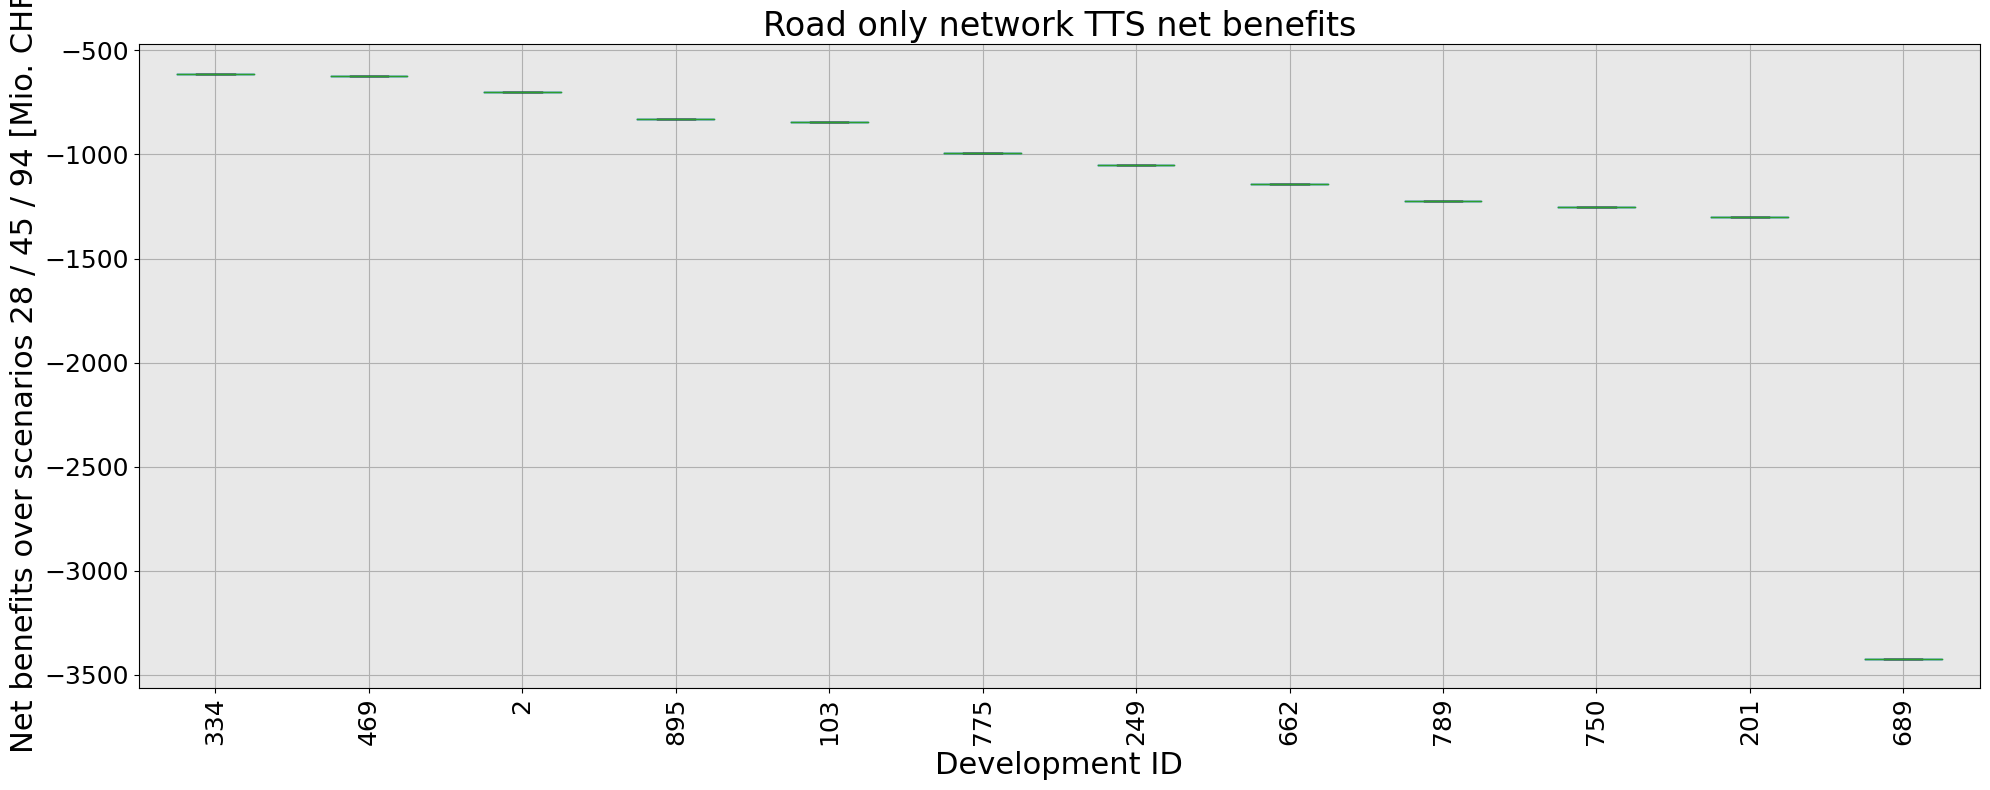

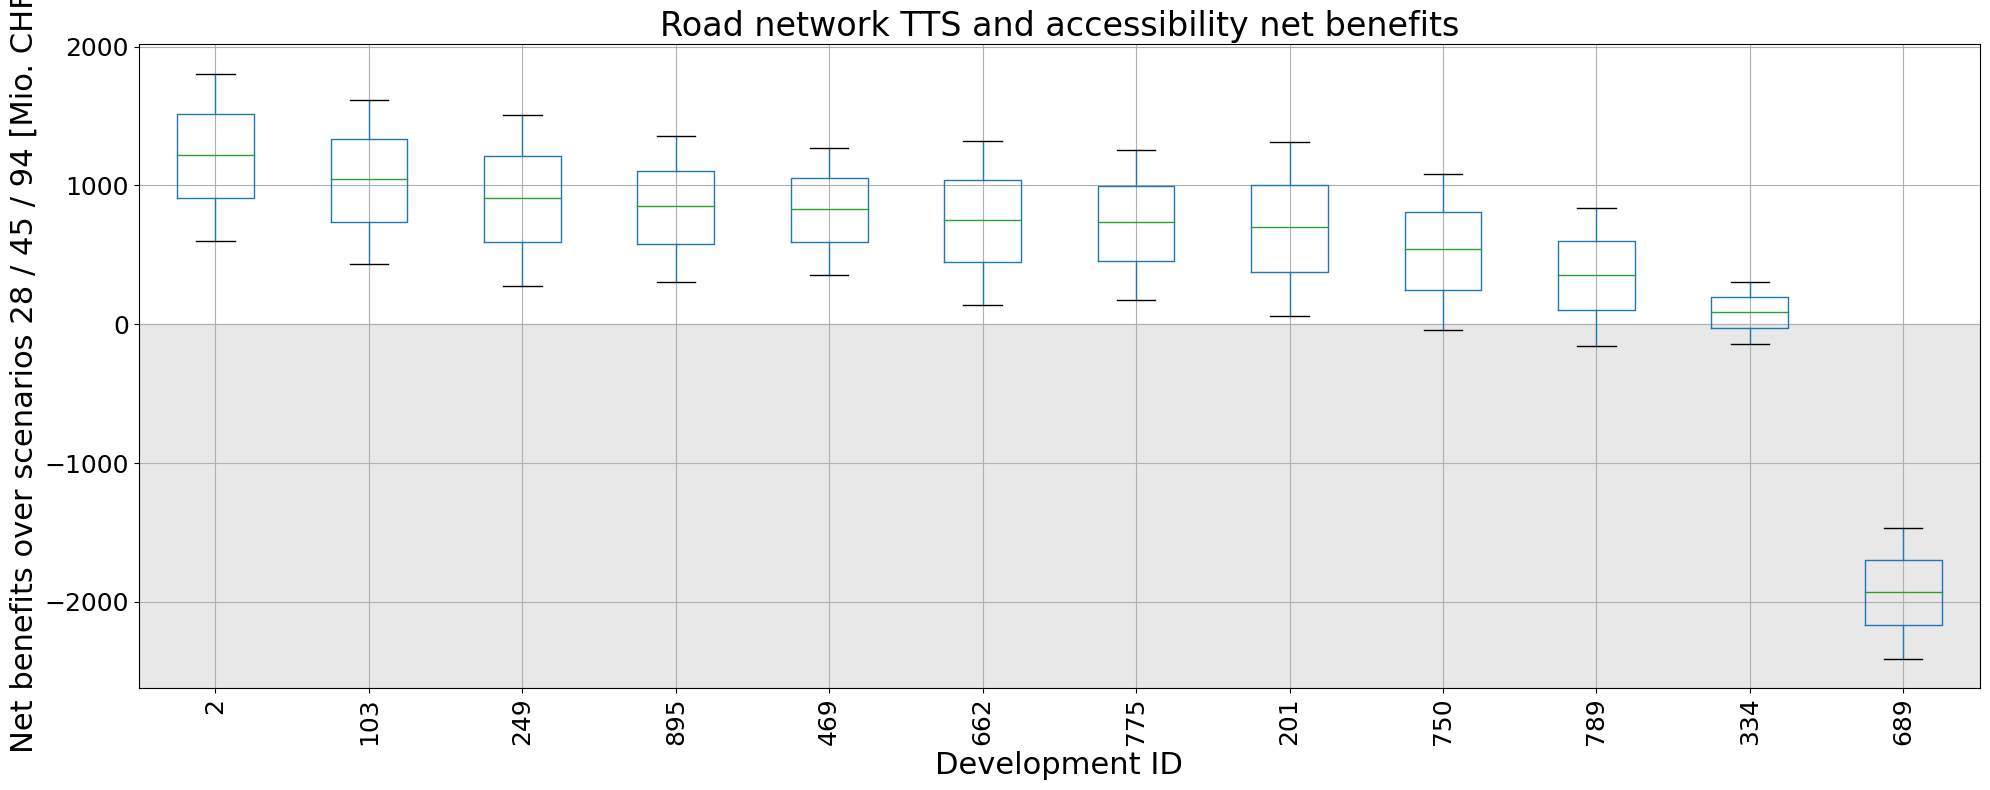

In [3]:

# Real boxplots per approach across scenarios 28 / 45 / 94
# Development IDs remain on the x-axis because each development has three scenario values.

from pathlib import Path
import pandas as pd
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

DATA = Path('/Volumes/WD_Windows/MSc_Thesis')


def boxplot_three_scenarios(df, nbr, title):
    df = df.copy()
    # Convert to millions before calculating mean
    df[['total_low', 'total_medium', 'total_high']] = df[['total_low', 'total_medium', 'total_high']] / 1e6
    df['mean'] = df[['total_low', 'total_medium', 'total_high']].mean(axis=1)
    df = df.sort_values(by='mean', ascending=False).head(nbr)
    df_top = df[['ID_new', 'total_low', 'total_medium', 'total_high']].set_index('ID_new').T

    plt.figure(figsize=(20, 8))
    df_top.boxplot()
    
    # Color area of y<0 with light grey (matches infraScanRoad/plots.py)
    ymin, ymax = plt.ylim()
    plt.axhspan(ymin, 0, color='lightgrey', alpha=0.5)
    plt.ylim(ymin, ymax)
    
    plt.title(title, fontsize=24)
    plt.xlabel('Development ID', fontsize=22)
    plt.ylabel('Net benefits over scenarios 28 / 45 / 94 [Mio. CHF]', fontsize=22)
    plt.xticks(fontsize=18, rotation=90)
    plt.yticks(fontsize=18)
    plt.tight_layout()
    plt.show()



agg = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_aggregate.csv')
agg_box = agg[['ID_new', 'total_scenario_28', 'total_scenario_45', 'total_scenario_94']].rename(columns={
    'total_scenario_28': 'total_low',
    'total_scenario_45': 'total_medium',
    'total_scenario_94': 'total_high',
})

od = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_od.csv')
od_box = od[['ID_new', 'total_scenario_28', 'total_scenario_45', 'total_scenario_94']].rename(columns={
    'total_scenario_28': 'total_low',
    'total_scenario_45': 'total_medium',
    'total_scenario_94': 'total_high',
})



new_box = pd.DataFrame({'ID_new': detail_tables['scenario_45']['development']})
new_box['total_low'] = detail_tables['scenario_28']['agg_total_connector_only']
new_box['total_medium'] = detail_tables['scenario_45']['agg_total_connector_only']
new_box['total_high'] = detail_tables['scenario_94']['agg_total_connector_only']

new_box2 = pd.DataFrame({'ID_new': detail_tables['scenario_45']['development']})
new_box2['total_low'] = detail_tables['scenario_28']['od_total_minus_tt_plus_connector']
new_box2['total_medium'] = detail_tables['scenario_45']['od_total_minus_tt_plus_connector']
new_box2['total_high'] = detail_tables['scenario_94']['od_total_minus_tt_plus_connector']

N = len(agg_box)
boxplot_three_scenarios(agg_box, N, 'Road aggregate net benefits')
boxplot_three_scenarios(od_box, N, 'Road OD/raster net benefits')
boxplot_three_scenarios(new_box, N, 'Road only network TTS net benefits')
boxplot_three_scenarios(new_box2, N, 'Road network TTS and accessibility net benefits')

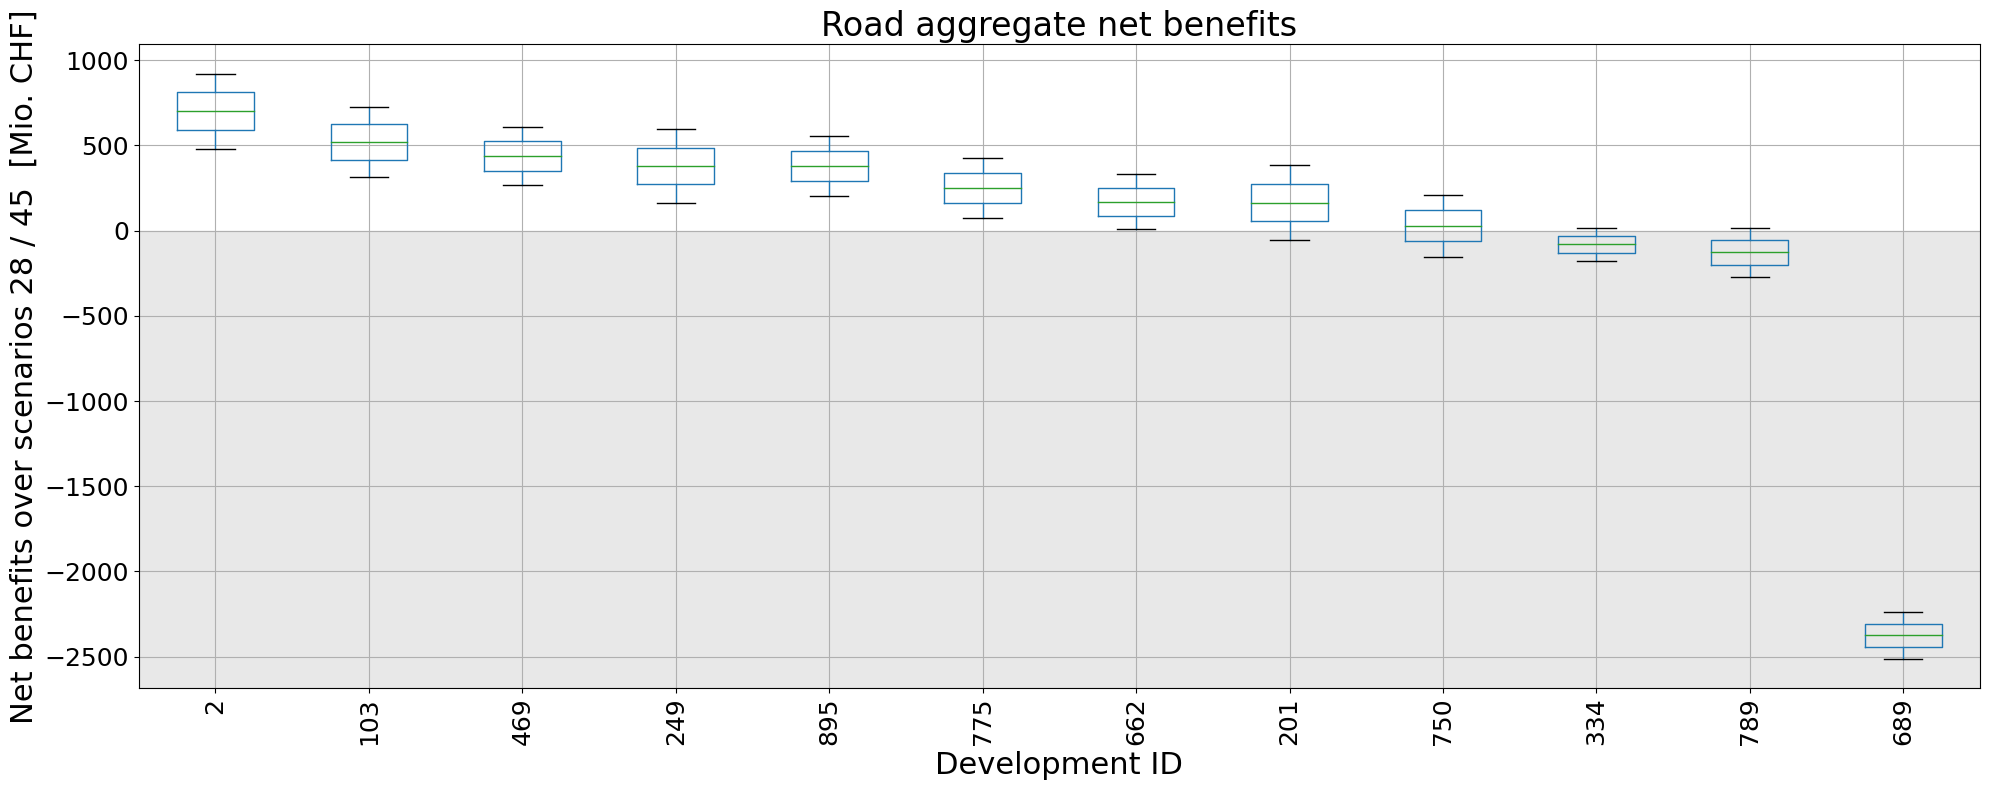

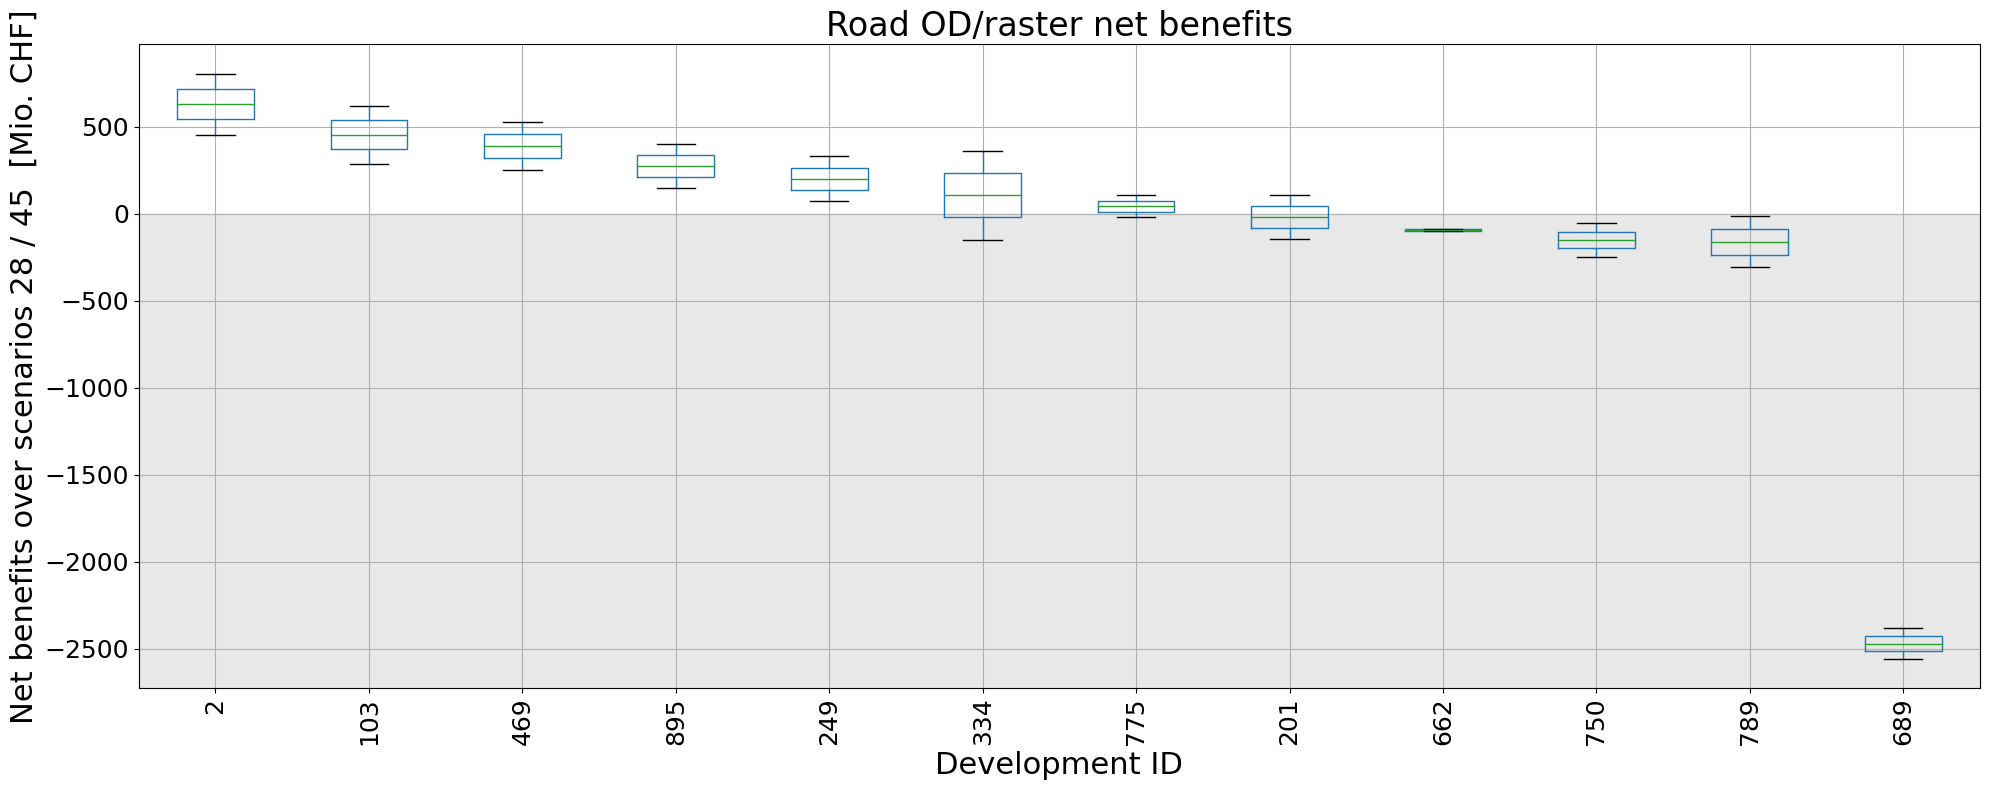

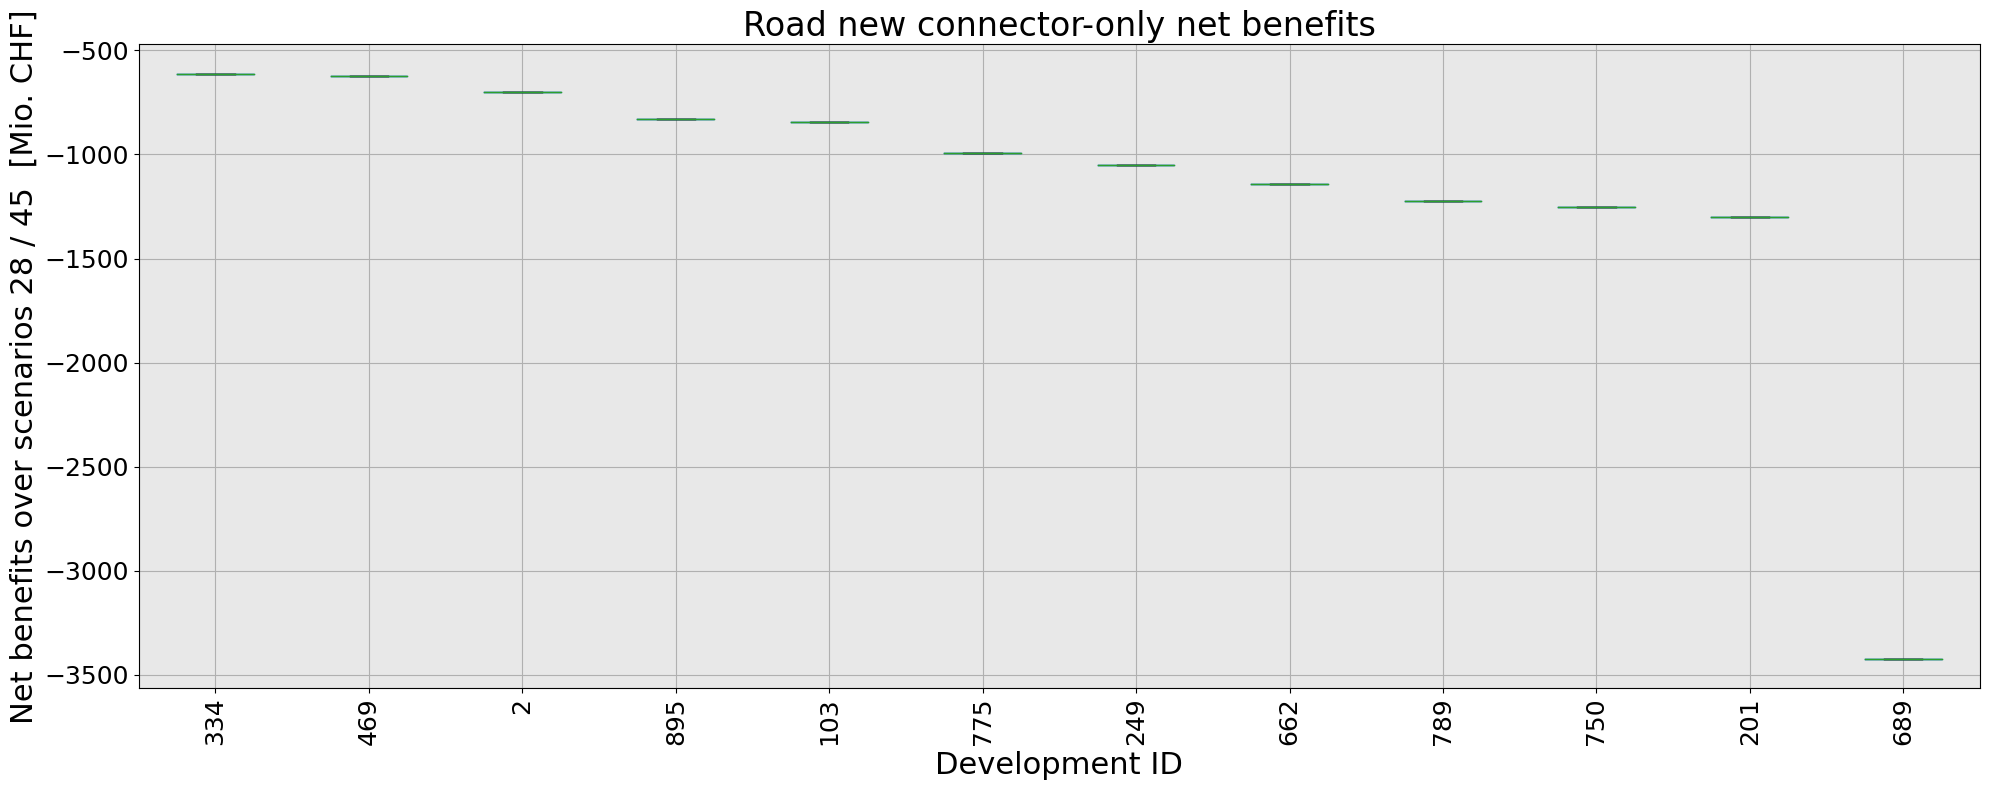

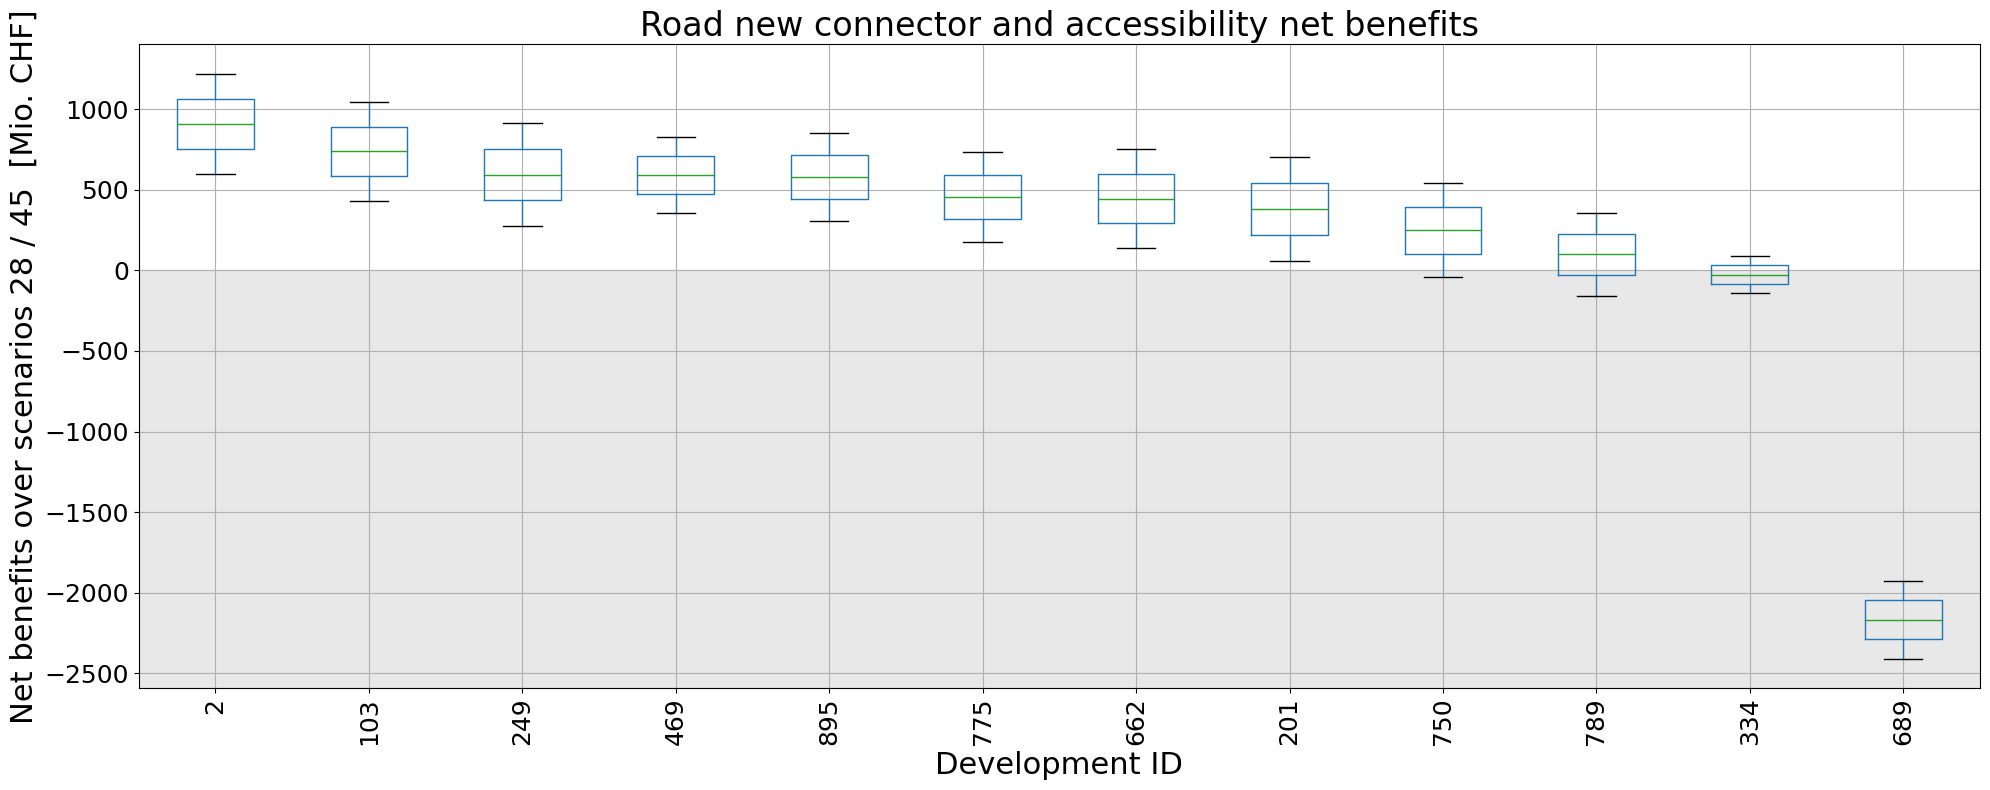

In [4]:

# Real boxplots per approach across scenarios 28 / 45 / 94
# Development IDs remain on the x-axis because each development has three scenario values.

from pathlib import Path
import pandas as pd
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

DATA = Path('/Volumes/WD_Windows/MSc_Thesis')



def boxplot_two_scenarios(df, nbr, title):
    df = df.copy()
    # Convert to millions before calculating mean
    df[['total_low', 'total_medium']] = df[['total_low', 'total_medium']] / 1e6
    df['mean'] = df[['total_low', 'total_medium']].mean(axis=1)
    df = df.sort_values(by='mean', ascending=False).head(nbr)
    df_top = df[['ID_new', 'total_low', 'total_medium']].set_index('ID_new').T

    plt.figure(figsize=(20, 8))
    df_top.boxplot()
    
    # Color area of y<0 with light grey (matches infraScanRoad/plots.py)
    ymin, ymax = plt.ylim()
    plt.axhspan(ymin, 0, color='lightgrey', alpha=0.5)
    plt.ylim(ymin, ymax)
    plt.title(title, fontsize=24)
    plt.xlabel('Development ID', fontsize=22)
    plt.ylabel('Net benefits over scenarios 28 / 45  [Mio. CHF]', fontsize=22)
    plt.xticks(fontsize=18, rotation=90)
    plt.yticks(fontsize=18)
    plt.tight_layout()
    plt.show()

agg = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_aggregate.csv')
agg_box = agg[['ID_new', 'total_scenario_28', 'total_scenario_45']].rename(columns={
    'total_scenario_28': 'total_low',
    'total_scenario_45': 'total_medium',
})

od = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_od.csv')
od_box = od[['ID_new', 'total_scenario_28', 'total_scenario_45']].rename(columns={
    'total_scenario_28': 'total_low',
    'total_scenario_45': 'total_medium',
})



new_box = pd.DataFrame({'ID_new': detail_tables['scenario_45']['development']})
new_box['total_low'] = detail_tables['scenario_28']['agg_total_connector_only']
new_box['total_medium'] = detail_tables['scenario_45']['agg_total_connector_only']


new_box2 = pd.DataFrame({'ID_new': detail_tables['scenario_45']['development']})
new_box2['total_low'] = detail_tables['scenario_28']['od_total_minus_tt_plus_connector']
new_box2['total_medium'] = detail_tables['scenario_45']['od_total_minus_tt_plus_connector']


N = len(agg_box)
boxplot_two_scenarios(agg_box, N, 'Road aggregate net benefits')
boxplot_two_scenarios(od_box, N, 'Road OD/raster net benefits')
boxplot_two_scenarios(new_box, N, 'Road new connector-only net benefits')
boxplot_two_scenarios(new_box2, N, 'Road new connector and accessibility net benefits')

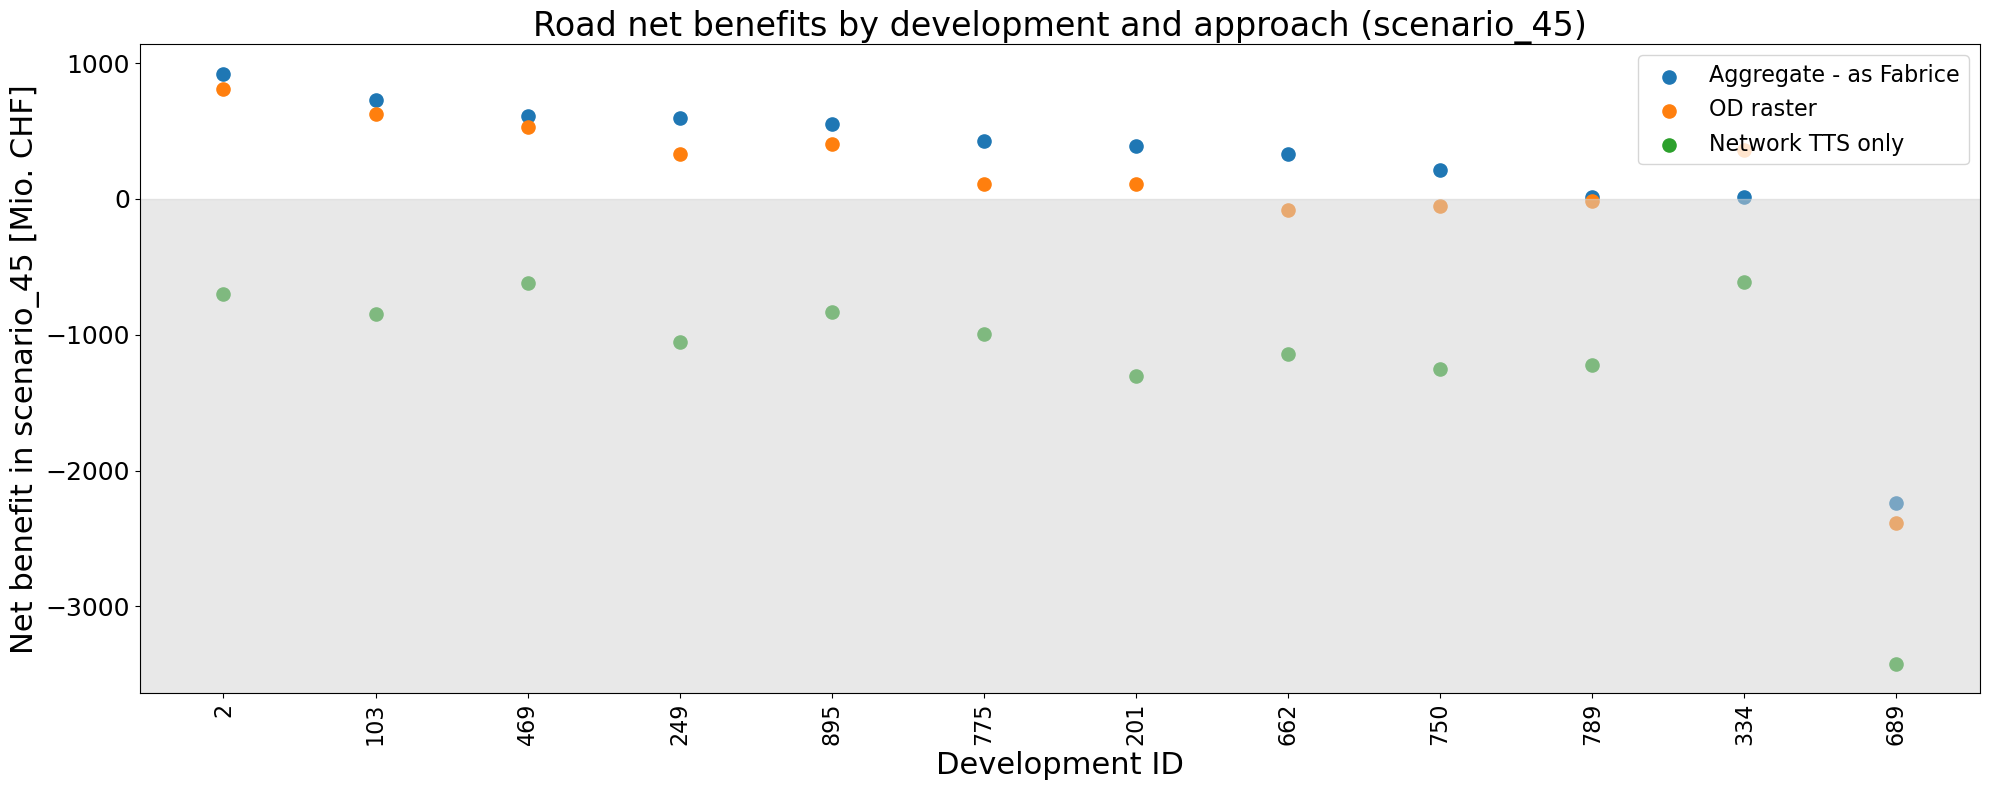

,ID_new,aggregate,od_raster,new_connector_only
0,2,921.344333,806.464437,-702.023469
1,103,727.188340,622.145251,-843.215901
2,469,609.912387,526.551387,-622.025740
3,249,595.029261,330.526635,-1050.525219
4,895,555.464144,401.792800,-828.542606
5,775,425.065593,107.405982,-991.822274
6,201,386.760112,110.189078,-1300.916751
7,662,331.055591,-84.752704,-1143.128420
8,750,211.154604,-54.777799,-1251.488017
9,789,15.535807,-14.027520,-1223.708058


In [6]:

# Joint comparison of net benefits per development for scenario_45
# Points only.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt

DATA = Path('/Volumes/WD_Windows/MSc_Thesis')

agg = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_aggregate.csv')[['ID_new', 'total_scenario_45']].rename(columns={'total_scenario_45': 'aggregate'})
od = pd.read_csv(DATA / 'data/infraScanRoad/costs/total_costs_od.csv')[['ID_new', 'total_scenario_45']].rename(columns={'total_scenario_45': 'od_raster'})
new = detail_tables['scenario_45'][['development', 'agg_total_connector_only']].rename(columns={'development': 'ID_new', 'agg_total_connector_only': 'new_connector_only'})

compare = agg.merge(od, on='ID_new').merge(new, on='ID_new')
compare = compare.sort_values('aggregate', ascending=False).reset_index(drop=True)
for col in ['aggregate', 'od_raster', 'new_connector_only']:
    compare[col] = compare[col] / 1e6

x = np.arange(len(compare))
plt.figure(figsize=(20, 8))
plt.scatter(x, compare['aggregate'], s=90, label='Aggregate - as Fabrice')
plt.scatter(x, compare['od_raster'], s=90, label='OD raster')
plt.scatter(x, compare['new_connector_only'], s=90, label='Network TTS only')

# Color area of y<0 with light grey (matches infraScanRoad/plots.py)
ymin, ymax = plt.ylim()
plt.axhspan(ymin, 0, color='lightgrey', alpha=0.5)
plt.ylim(ymin, ymax)

plt.xticks(x, compare['ID_new'].astype(str), rotation=90, fontsize=16)
plt.yticks(fontsize=18)
plt.xlabel('Development ID', fontsize=22)
plt.ylabel('Net benefit in scenario_45 [Mio. CHF]', fontsize=22)
plt.title('Road net benefits by development and approach (scenario_45)', fontsize=24)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

display(compare)